In [107]:
import pandas as pd

In [108]:
df = pd.read_csv('engineered_climate_features_correlation_analyzed.csv')

In [109]:
df

,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,swvl1_kharif_mean,soil_air_diff_kharif_mean,soil_air_diff_kharif_std,runoff_ratio_kharif_mean,e_rabi_mean,...,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,5.571480e-07,1.401477,0.055918,0.000000,-0.124398,...,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,1.246314e-01,1.206633,0.090948,0.127147,-0.133948,...,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,1.675441e-02,1.314073,0.136034,0.024587,-0.137583,...,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,3.896810e-01,0.550737,0.154662,0.452236,-0.079284,...,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,2.852737e-01,0.548313,0.174455,0.237716,-0.086047,...,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,West Bengal_Murshidabad,0.275707,0.021696,-0.112844,0.002819,3.844570e-01,0.641541,0.069157,0.356913,-0.073634,...,46.448733,2,0,1.888184,0.212852,0.553644,1.418102e-01,0.333241,-0.090637,2.708996
769,West Bengal_Nadia,0.278344,0.025523,-0.114582,0.002691,3.855084e-01,0.673007,0.080176,0.361696,-0.077410,...,47.466119,2,0,1.631112,0.208986,0.542105,1.389152e-01,0.082477,-0.103035,2.954232
770,West Bengal_Paschim Bardhaman,0.253455,0.021283,-0.109788,0.001778,3.772881e-01,0.754295,0.127140,0.257821,-0.070918,...,44.891160,3,0,2.463836,0.218843,0.580043,1.424418e-01,0.344329,-0.068096,2.365677
771,West Bengal_Purba Bardhaman,0.270052,0.023807,-0.110861,0.002242,3.840139e-01,0.635673,0.069839,0.336611,-0.072089,...,47.207326,3,0,1.842454,0.212822,0.554204,1.423393e-01,0.354676,-0.079435,2.812093


In [110]:
from sklearn.preprocessing import StandardScaler

# Separate location column
locations = df['location'].values

# Get all feature columns (exclude location and categorical variables)
feature_cols = [col for col in df.columns 
                if col not in ['location', 'cvh', 'cvl', 'slt']]

# Extract features
X = df[feature_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

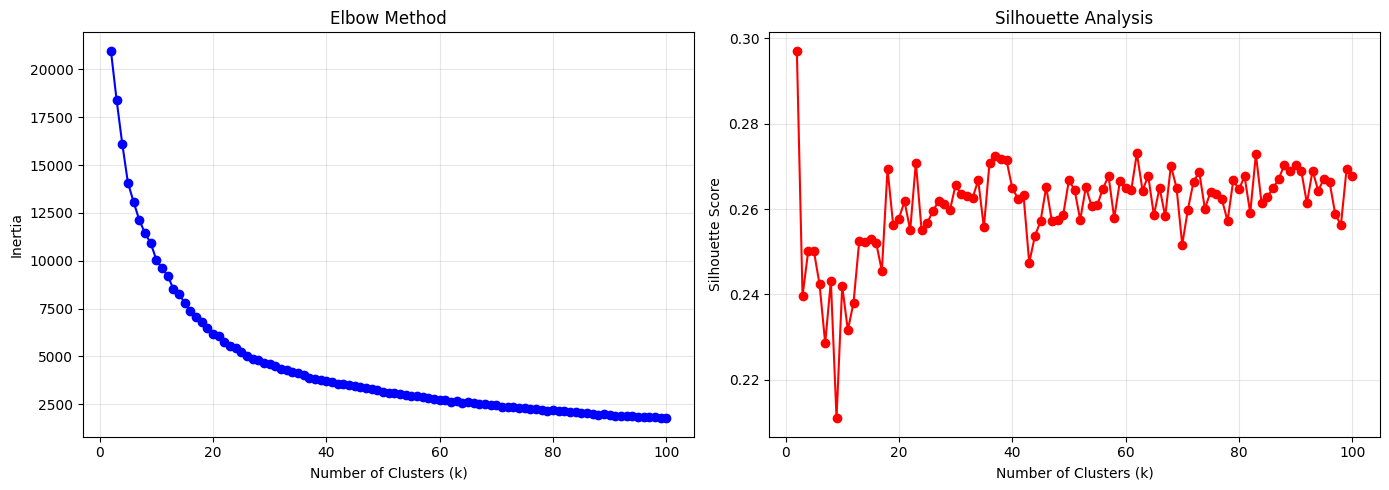

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

max_k = 100
inertias = []
silhouette_scores = []
k_range = range(2, max_k + 1)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



K-Means Evaluation:
  Number of clusters: 20
  Silhouette Score: 0.2578
  Davies-Bouldin Index: 1.1116
  Calinski-Harabasz Index: 133.59


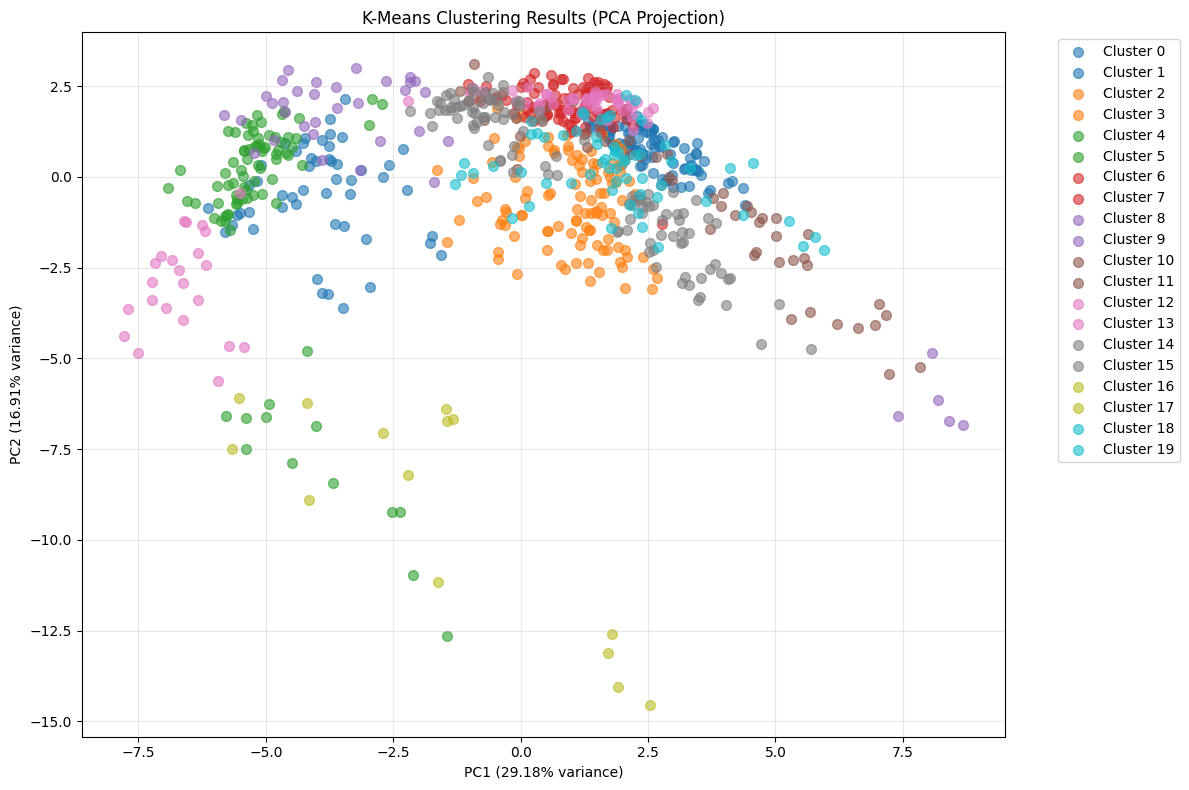


K-Means Cluster Summary:

Cluster 0:
  Size: 91 locations
  Sample locations: Bihar_Kaimur (Bhabua), Bihar_Rohtas, Gujarat_Amreli, Gujarat_Arvalli, Gujarat_Dohad
  Avg annual rainfall: 0.22
  Avg annual temp: 0.91 K

Cluster 1:
  Size: 51 locations
  Sample locations: Himachal Pradesh_Kangra, Himachal Pradesh_Mandi, Himachal Pradesh_Shimla, Himachal Pradesh_Sirmaur, Jammu & Kashmir_Kathua
  Avg annual rainfall: 0.32
  Avg annual temp: 0.68 K

Cluster 2:
  Size: 64 locations
  Sample locations: Delhi_South East, Haryana_Ambala, Haryana_Karnal, Haryana_Kurukshetra, Haryana_Panchkula
  Avg annual rainfall: 0.19
  Avg annual temp: 0.77 K

Cluster 3:
  Size: 46 locations
  Sample locations: A & N Islands_North And Middle Andaman, A & N Islands_South Andamans, Andhra Pradesh_Annamayya, Andhra Pradesh_Chittoor, Andhra Pradesh_Prakasam
  Avg annual rainfall: 0.11
  Avg annual temp: 0.38 K

Cluster 4:
  Size: 13 locations
  Sample locations: Jammu & Kashmir_Anantnag, Jammu & Kashmir_Bandipora,

In [112]:
import numpy as np

n_clusters = 20

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate K-Means
print("\nK-Means Evaluation:")
print(f"  Number of clusters: {len(np.unique(kmeans_labels))}")

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {kmeans_calinski_harabasz:.2f}")

# Visualize K-Means with PCA
pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in range(n_clusters):
    mask = kmeans_labels == label
    plt.scatter(X_pca_kmeans[mask, 0], X_pca_kmeans[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_kmeans.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_kmeans.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K-Means cluster summary
kmeans_df = df.copy()
kmeans_df['cluster'] = kmeans_labels

print("\nK-Means Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(kmeans_df['cluster'].unique()):
    cluster_data = kmeans_df[kmeans_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")


In [113]:
# separate location column into state and district from underscore in the kmeans_df
kmeans_df[['state', 'district']] = kmeans_df['location'].str.split('_', expand=True)
kmeans_df.to_csv('kmeans_clustering_results_new.csv', index=False)

In [114]:
comparison_df = pd.read_csv('for_comparison.csv')

In [115]:
comparison_df

,district,label,label_name
0,A & N Islands_Nicobars,15,Islands Region
1,A & N Islands_North And Middle Andaman,15,Islands Region
2,A & N Islands_South Andamans,15,Islands Region
3,Andhra Pradesh_Alluri Sitharama Raju,11,East Coast Plains and Hills Region
4,Andhra Pradesh_Anakapalli,11,East Coast Plains and Hills Region
...,...,...,...
768,West Bengal_Murshidabad,3,Lower Gangetic Plains Region
769,West Bengal_Nadia,3,Lower Gangetic Plains Region
770,West Bengal_Paschim Bardhaman,3,Lower Gangetic Plains Region
771,West Bengal_Purba Bardhaman,3,Lower Gangetic Plains Region


In [116]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(comparison_df['label'], kmeans_df['cluster'])

0.4387068281963356


GMM Evaluation:
  Number of clusters: 20
  Silhouette Score: 0.2527
  Davies-Bouldin Index: 1.1643
  Calinski-Harabasz Index: 127.74


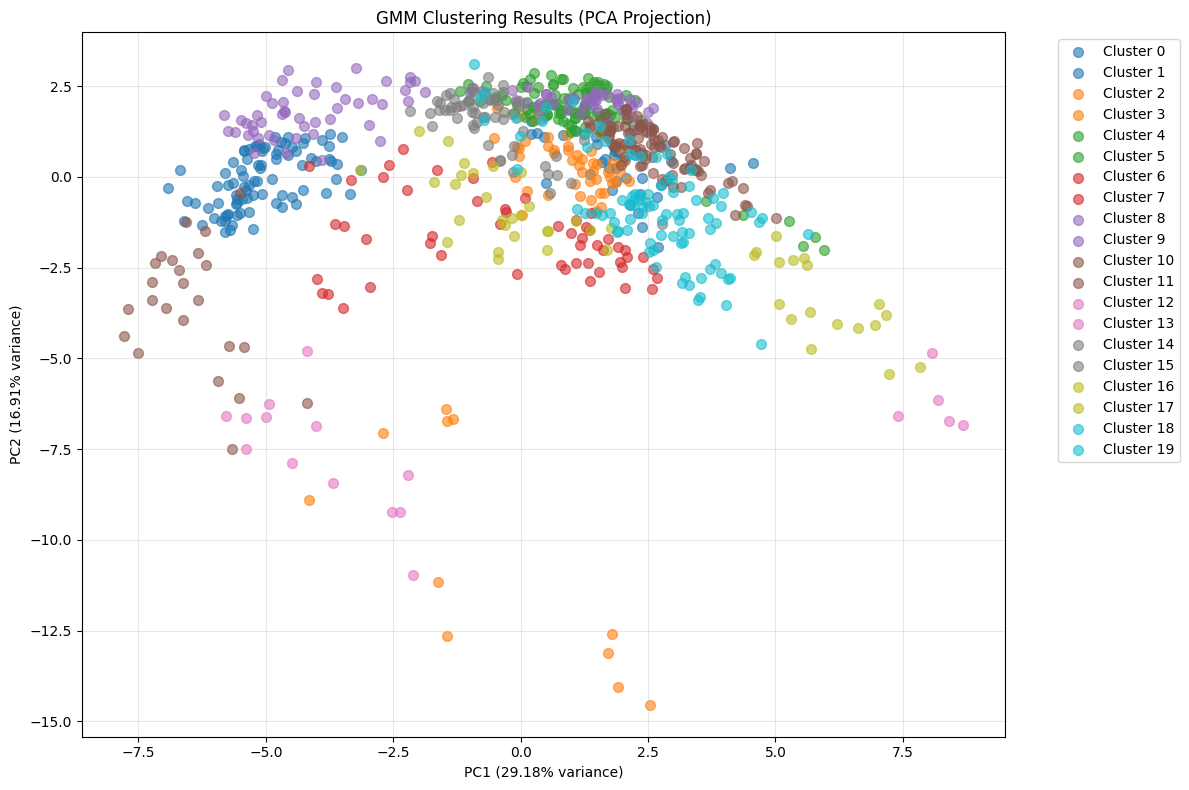


GMM Cluster Summary:

Cluster 0:
  Size: 38 locations
  Sample locations: Andhra Pradesh_Anantapur, Andhra Pradesh_Kurnool, Andhra Pradesh_Nandyal, Andhra Pradesh_Y.s.r., Karnataka_Bagalkote
  Avg annual rainfall: 0.16
  Avg annual temp: 0.75 K

Cluster 1:
  Size: 87 locations
  Sample locations: Arunachal Pradesh_Changlang, Arunachal Pradesh_East Siang, Arunachal Pradesh_Itanagar Capital Complex, Arunachal Pradesh_Longding, Arunachal Pradesh_Lower Siang
  Avg annual rainfall: 0.40
  Avg annual temp: 0.65 K

Cluster 2:
  Size: 50 locations
  Sample locations: Haryana_Ambala, Haryana_Karnal, Haryana_Kurukshetra, Haryana_Panchkula, Haryana_Yamunanagar
  Avg annual rainfall: 0.19
  Avg annual temp: 0.79 K

Cluster 3:
  Size: 11 locations
  Sample locations: Himachal Pradesh_Kinnaur, Himachal Pradesh_Kullu, Himachal Pradesh_Lahul And Spiti, Jammu & Kashmir_Bandipora, Jammu & Kashmir_Kishtwar
  Avg annual rainfall: 0.18
  Avg annual temp: 0.46 K

Cluster 4:
  Size: 93 locations
  Sample lo

In [117]:
gmm = GaussianMixture(n_components=n_clusters, random_state=42, 
                      covariance_type='full', n_init=5)
gmm_labels = gmm.fit_predict(X_scaled)

# Evaluate GMM
print("\nGMM Evaluation:")
print(f"  Number of clusters: {len(np.unique(gmm_labels))}")

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_davies_bouldin = davies_bouldin_score(X_scaled, gmm_labels)
gmm_calinski_harabasz = calinski_harabasz_score(X_scaled, gmm_labels)

print(f"  Silhouette Score: {gmm_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {gmm_calinski_harabasz:.2f}")

# Visualize GMM with PCA
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = gmm_labels == label
    plt.scatter(X_pca_gmm[mask, 0], X_pca_gmm[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_gmm.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_gmm.explained_variance_ratio_[1]:.2%} variance)')
plt.title('GMM Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GMM cluster summary
gmm_df = df.copy()
gmm_df['cluster'] = gmm_labels

print("\nGMM Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(gmm_df['cluster'].unique()):
    cluster_data = gmm_df[gmm_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")


In [118]:
gmm_df[['state', 'district']] = gmm_df['location'].str.split('_', expand=True)
gmm_df.to_csv('gmm_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], gmm_df['cluster'])

0.5063298729834053


Hierarchical Evaluation:
  Number of clusters: 20
  Silhouette Score: 0.2313
  Davies-Bouldin Index: 1.1551
  Calinski-Harabasz Index: 119.93


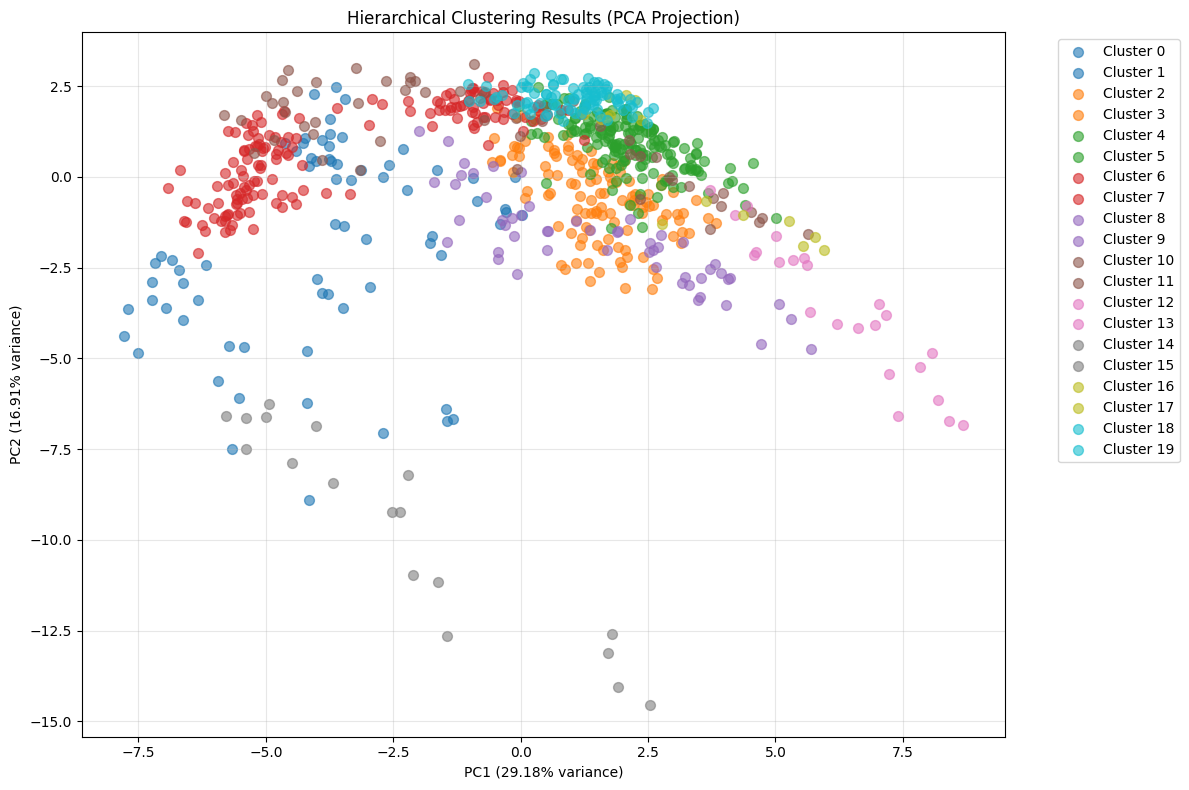


Hierarchical Cluster Summary:

Cluster 0:
  Size: 25 locations
  Sample locations: Arunachal Pradesh_Anjaw, Arunachal Pradesh_Dibang Valley, Arunachal Pradesh_East Kameng, Arunachal Pradesh_Kamle, Arunachal Pradesh_Kra Daadi
  Avg annual rainfall: 0.56
  Avg annual temp: 0.58 K

Cluster 1:
  Size: 45 locations
  Sample locations: Himachal Pradesh_Bilaspur, Himachal Pradesh_Hamirpur, Himachal Pradesh_Kangra, Himachal Pradesh_Mandi, Himachal Pradesh_Shimla
  Avg annual rainfall: 0.29
  Avg annual temp: 0.67 K

Cluster 2:
  Size: 40 locations
  Sample locations: A & N Islands_North And Middle Andaman, A & N Islands_South Andamans, Andhra Pradesh_Anakapalli, Andhra Pradesh_Bapatla, Andhra Pradesh_Guntur
  Avg annual rainfall: 0.13
  Avg annual temp: 0.44 K

Cluster 3:
  Size: 81 locations
  Sample locations: Chandigarh_Chandigarh, Delhi_Central, Delhi_New Delhi, Delhi_North, Delhi_North West
  Avg annual rainfall: 0.17
  Avg annual temp: 0.79 K

Cluster 4:
  Size: 67 locations
  Sample lo

In [119]:
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

# Evaluate Hierarchical
print("\nHierarchical Evaluation:")
print(f"  Number of clusters: {len(np.unique(hier_labels))}")

hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_davies_bouldin = davies_bouldin_score(X_scaled, hier_labels)
hier_calinski_harabasz = calinski_harabasz_score(X_scaled, hier_labels)

print(f"  Silhouette Score: {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hier_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {hier_calinski_harabasz:.2f}")

# Visualize Hierarchical with PCA
pca_hier = PCA(n_components=2)
X_pca_hier = pca_hier.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = hier_labels == label
    plt.scatter(X_pca_hier[mask, 0], X_pca_hier[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_hier.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_hier.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Hierarchical Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hierarchical cluster summary
hier_df = df.copy()
hier_df['cluster'] = hier_labels

print("\nHierarchical Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(hier_df['cluster'].unique()):
    cluster_data = hier_df[hier_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_kharif_mean'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['tp_kharif_fraction'].mean():.2f} K")

In [120]:
hier_df[['state', 'district']] = hier_df['location'].str.split('_', expand=True)
hier_df.to_csv('hier_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], hier_df['cluster'])

0.4923358593201403

k= 2 | KMeans: 0.098 | GMM: 0.102 | Hier: 0.110
k= 3 | KMeans: 0.198 | GMM: 0.164 | Hier: 0.147
k= 4 | KMeans: 0.200 | GMM: 0.169 | Hier: 0.122
k= 5 | KMeans: 0.253 | GMM: 0.314 | Hier: 0.232
k= 6 | KMeans: 0.286 | GMM: 0.312 | Hier: 0.346
k= 7 | KMeans: 0.363 | GMM: 0.370 | Hier: 0.347
k= 8 | KMeans: 0.421 | GMM: 0.425 | Hier: 0.339
k= 9 | KMeans: 0.330 | GMM: 0.383 | Hier: 0.339
k=10 | KMeans: 0.380 | GMM: 0.351 | Hier: 0.376
k=11 | KMeans: 0.367 | GMM: 0.349 | Hier: 0.404
k=12 | KMeans: 0.454 | GMM: 0.405 | Hier: 0.422
k=13 | KMeans: 0.424 | GMM: 0.400 | Hier: 0.422
k=14 | KMeans: 0.386 | GMM: 0.400 | Hier: 0.401
k=15 | KMeans: 0.442 | GMM: 0.406 | Hier: 0.399
k=16 | KMeans: 0.509 | GMM: 0.434 | Hier: 0.442
k=17 | KMeans: 0.388 | GMM: 0.428 | Hier: 0.445
k=18 | KMeans: 0.457 | GMM: 0.465 | Hier: 0.486
k=19 | KMeans: 0.431 | GMM: 0.467 | Hier: 0.492
k=20 | KMeans: 0.439 | GMM: 0.506 | Hier: 0.492
k=21 | KMeans: 0.421 | GMM: 0.421 | Hier: 0.490
k=22 | KMeans: 0.396 | GMM: 0.436 | Hier

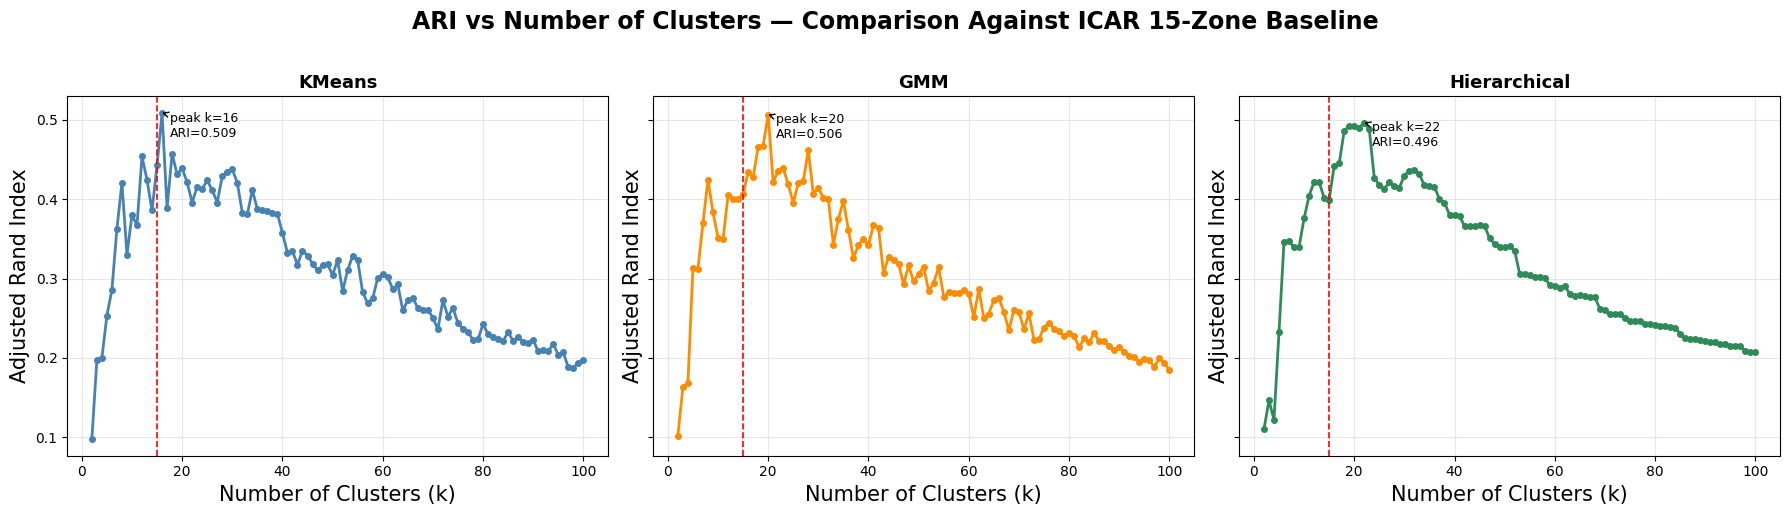

In [133]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

k_range = range(2, 101)
true_labels = comparison_df['label'].values

ari_kmeans = []
ari_gmm    = []
ari_hier   = []

for k in k_range:
    # KMeans
    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    ari_kmeans.append(adjusted_rand_score(true_labels, km_labels))

    # GMM
    gmm_labels_ = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5).fit_predict(X_scaled)
    ari_gmm.append(adjusted_rand_score(true_labels, gmm_labels_))

    # Hierarchical
    hier_labels_ = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    ari_hier.append(adjusted_rand_score(true_labels, hier_labels_))

    print(f"k={k:2d} | KMeans: {ari_kmeans[-1]:.3f} | GMM: {ari_gmm[-1]:.3f} | Hier: {ari_hier[-1]:.3f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, ari, algo_name, color in zip(
    axes,
    [ari_kmeans, ari_gmm, ari_hier],
    ['KMeans', 'GMM', 'Hierarchical'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.plot(k_range, ari, color=color, linewidth=2, marker='o', markersize=4)
    ax.axvline(x=15, color='red', linestyle='--', linewidth=1.2, label='k=15 (ICAR)')

    # Annotate peak
    best_k = list(k_range)[np.argmax(ari)]
    best_ari = max(ari)
    ax.annotate(f'peak k={best_k}\nARI={best_ari:.3f}',
                xy=(best_k, best_ari),
                xytext=(best_k + 1.5, best_ari - 0.03),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9)

    ax.set_title(algo_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)', fontsize=15)
    ax.set_ylabel('Adjusted Rand Index', fontsize=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('ARI vs Number of Clusters — Comparison Against ICAR 15-Zone Baseline', 
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("ari_vs_k_all_algos.png", dpi=150, bbox_inches='tight')
plt.show()

In [122]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Feature names (same as your feature_cols)
feature_names = feature_cols  

# ── Helper: fit RF → compute SHAP ──────────────────────────────────────────
def get_shap_values(X, labels, feature_names, algo_name):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, labels)

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X)  # list of arrays, one per class

    # shap_vals is a list of shape (n_classes,) each element: (n_samples, n_features)
    print(f"[{algo_name}] shap_values type: {type(shap_vals)}")
    if isinstance(shap_vals, list):
        print(f"[{algo_name}] n_classes: {len(shap_vals)}, per-class shape: {shap_vals[0].shape}")
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        # newer shap versions return a single 3D array (n_samples, n_features, n_classes)
        print(f"[{algo_name}] shap_values shape: {shap_vals.shape}")
        mean_abs_shap = np.abs(shap_vals).mean(axis=(0, 2))  # mean over samples and classes

    print(f"[{algo_name}] mean_abs_shap shape: {mean_abs_shap.shape}, feature_names: {len(feature_names)}")

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    print(f"\n{'='*50}")
    print(f"  SHAP Feature Importance — {algo_name}")
    print(f"{'='*50}")
    print(importance_df.to_string(index=False))

    return shap_vals, explainer, importance_df

# ── Run for each algorithm ──────────────────────────────────────────────────
shap_kmeans,  exp_kmeans,  imp_kmeans  = get_shap_values(X_scaled, kmeans_labels,  feature_names, "KMeans")
shap_gmm,     exp_gmm,     imp_gmm     = get_shap_values(X_scaled, gmm_labels,     feature_names, "GMM")
shap_hier,    exp_hier,    imp_hier    = get_shap_values(X_scaled, hier_labels,    feature_names, "Hierarchical")

[KMeans] shap_values type: <class 'numpy.ndarray'>
[KMeans] shap_values shape: (773, 35, 20)
[KMeans] mean_abs_shap shape: (35,), feature_names: 35

  SHAP Feature Importance — KMeans
                  feature  mean_abs_shap
     humidity_variability       0.010827
       tp_kharif_fraction       0.009702
             t2m_peak_sin       0.008457
             tp_zaid_mean       0.008358
           swvl1_rabi_std       0.008133
            t2m_amplitude       0.005984
                 GDD_rabi       0.005617
soil_moisture_seasonality       0.005555
 runoff_ratio_kharif_mean       0.005532
soil_air_diff_kharif_mean       0.004850
   runoff_ratio_rabi_mean       0.004594
             e_kharif_std       0.004306
           swvl1_zaid_std       0.004179
              e_zaid_mean       0.004144
             t2m_peak_cos       0.004099
   runoff_ratio_zaid_mean       0.004061
               GDD_kharif       0.004049
           tp_kharif_mean       0.004029
              e_rabi_mean       0.003

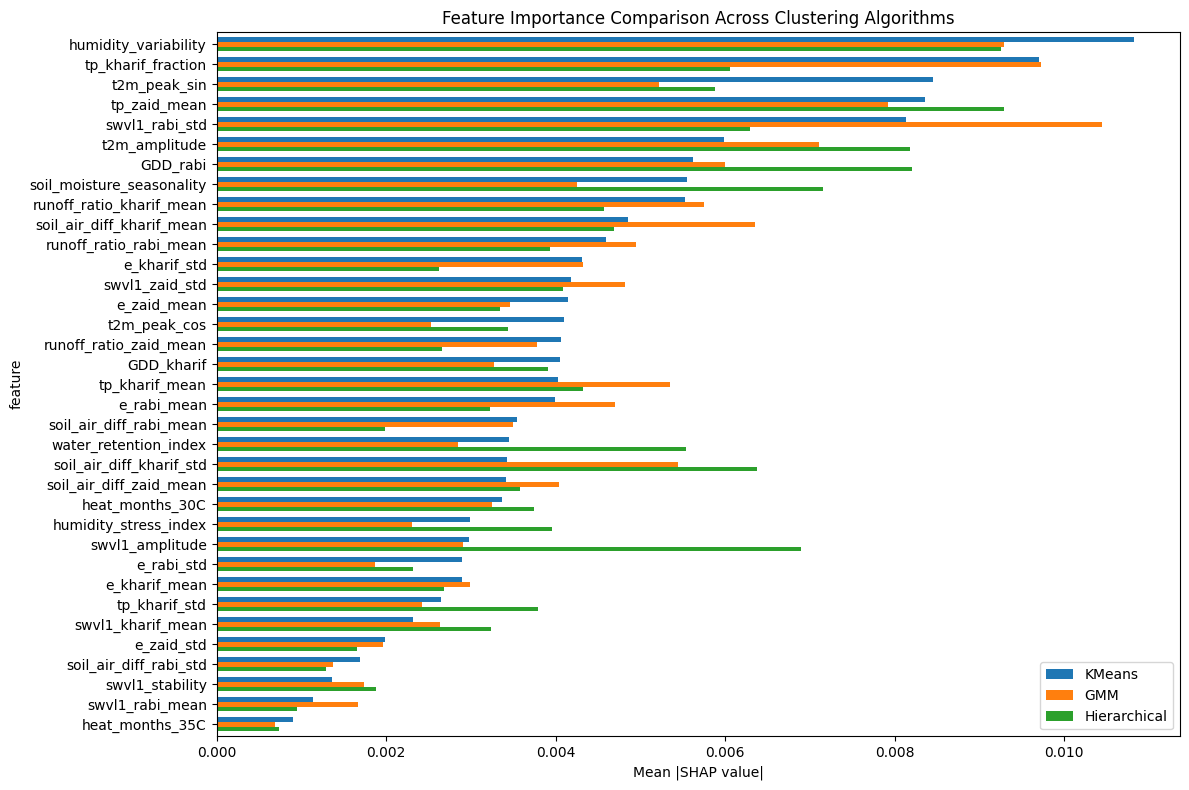

                             KMeans       GMM  Hierarchical
feature                                                    
humidity_variability       0.010827  0.009297      0.009253
tp_kharif_fraction         0.009702  0.009729      0.006064
t2m_peak_sin               0.008457  0.005222      0.005884
tp_zaid_mean               0.008358  0.007919      0.009293
swvl1_rabi_std             0.008133  0.010449      0.006297
t2m_amplitude              0.005984  0.007108      0.008180
GDD_rabi                   0.005617  0.005998      0.008211
soil_moisture_seasonality  0.005555  0.004251      0.007151
runoff_ratio_kharif_mean   0.005532  0.005748      0.004570
soil_air_diff_kharif_mean  0.004850  0.006356      0.004685
runoff_ratio_rabi_mean     0.004594  0.004946      0.003932
e_kharif_std               0.004306  0.004322      0.002621
swvl1_zaid_std             0.004179  0.004825      0.004089
e_zaid_mean                0.004144  0.003466      0.003341
t2m_peak_cos               0.004099  0.0

In [123]:
import pandas as pd

comparison = (
    imp_kmeans.rename(columns={'mean_abs_shap': 'KMeans'})
    .merge(imp_gmm.rename(columns={'mean_abs_shap': 'GMM'}), on='feature')
    .merge(imp_hier.rename(columns={'mean_abs_shap': 'Hierarchical'}), on='feature')
    .set_index('feature')
    .sort_values('KMeans', ascending=False)
)

comparison.plot(kind='barh', figsize=(12, 8), width=0.7)
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance Comparison Across Clustering Algorithms")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("shap_comparison_bar.png", dpi=150, bbox_inches='tight')
plt.show()

print(comparison.to_string())

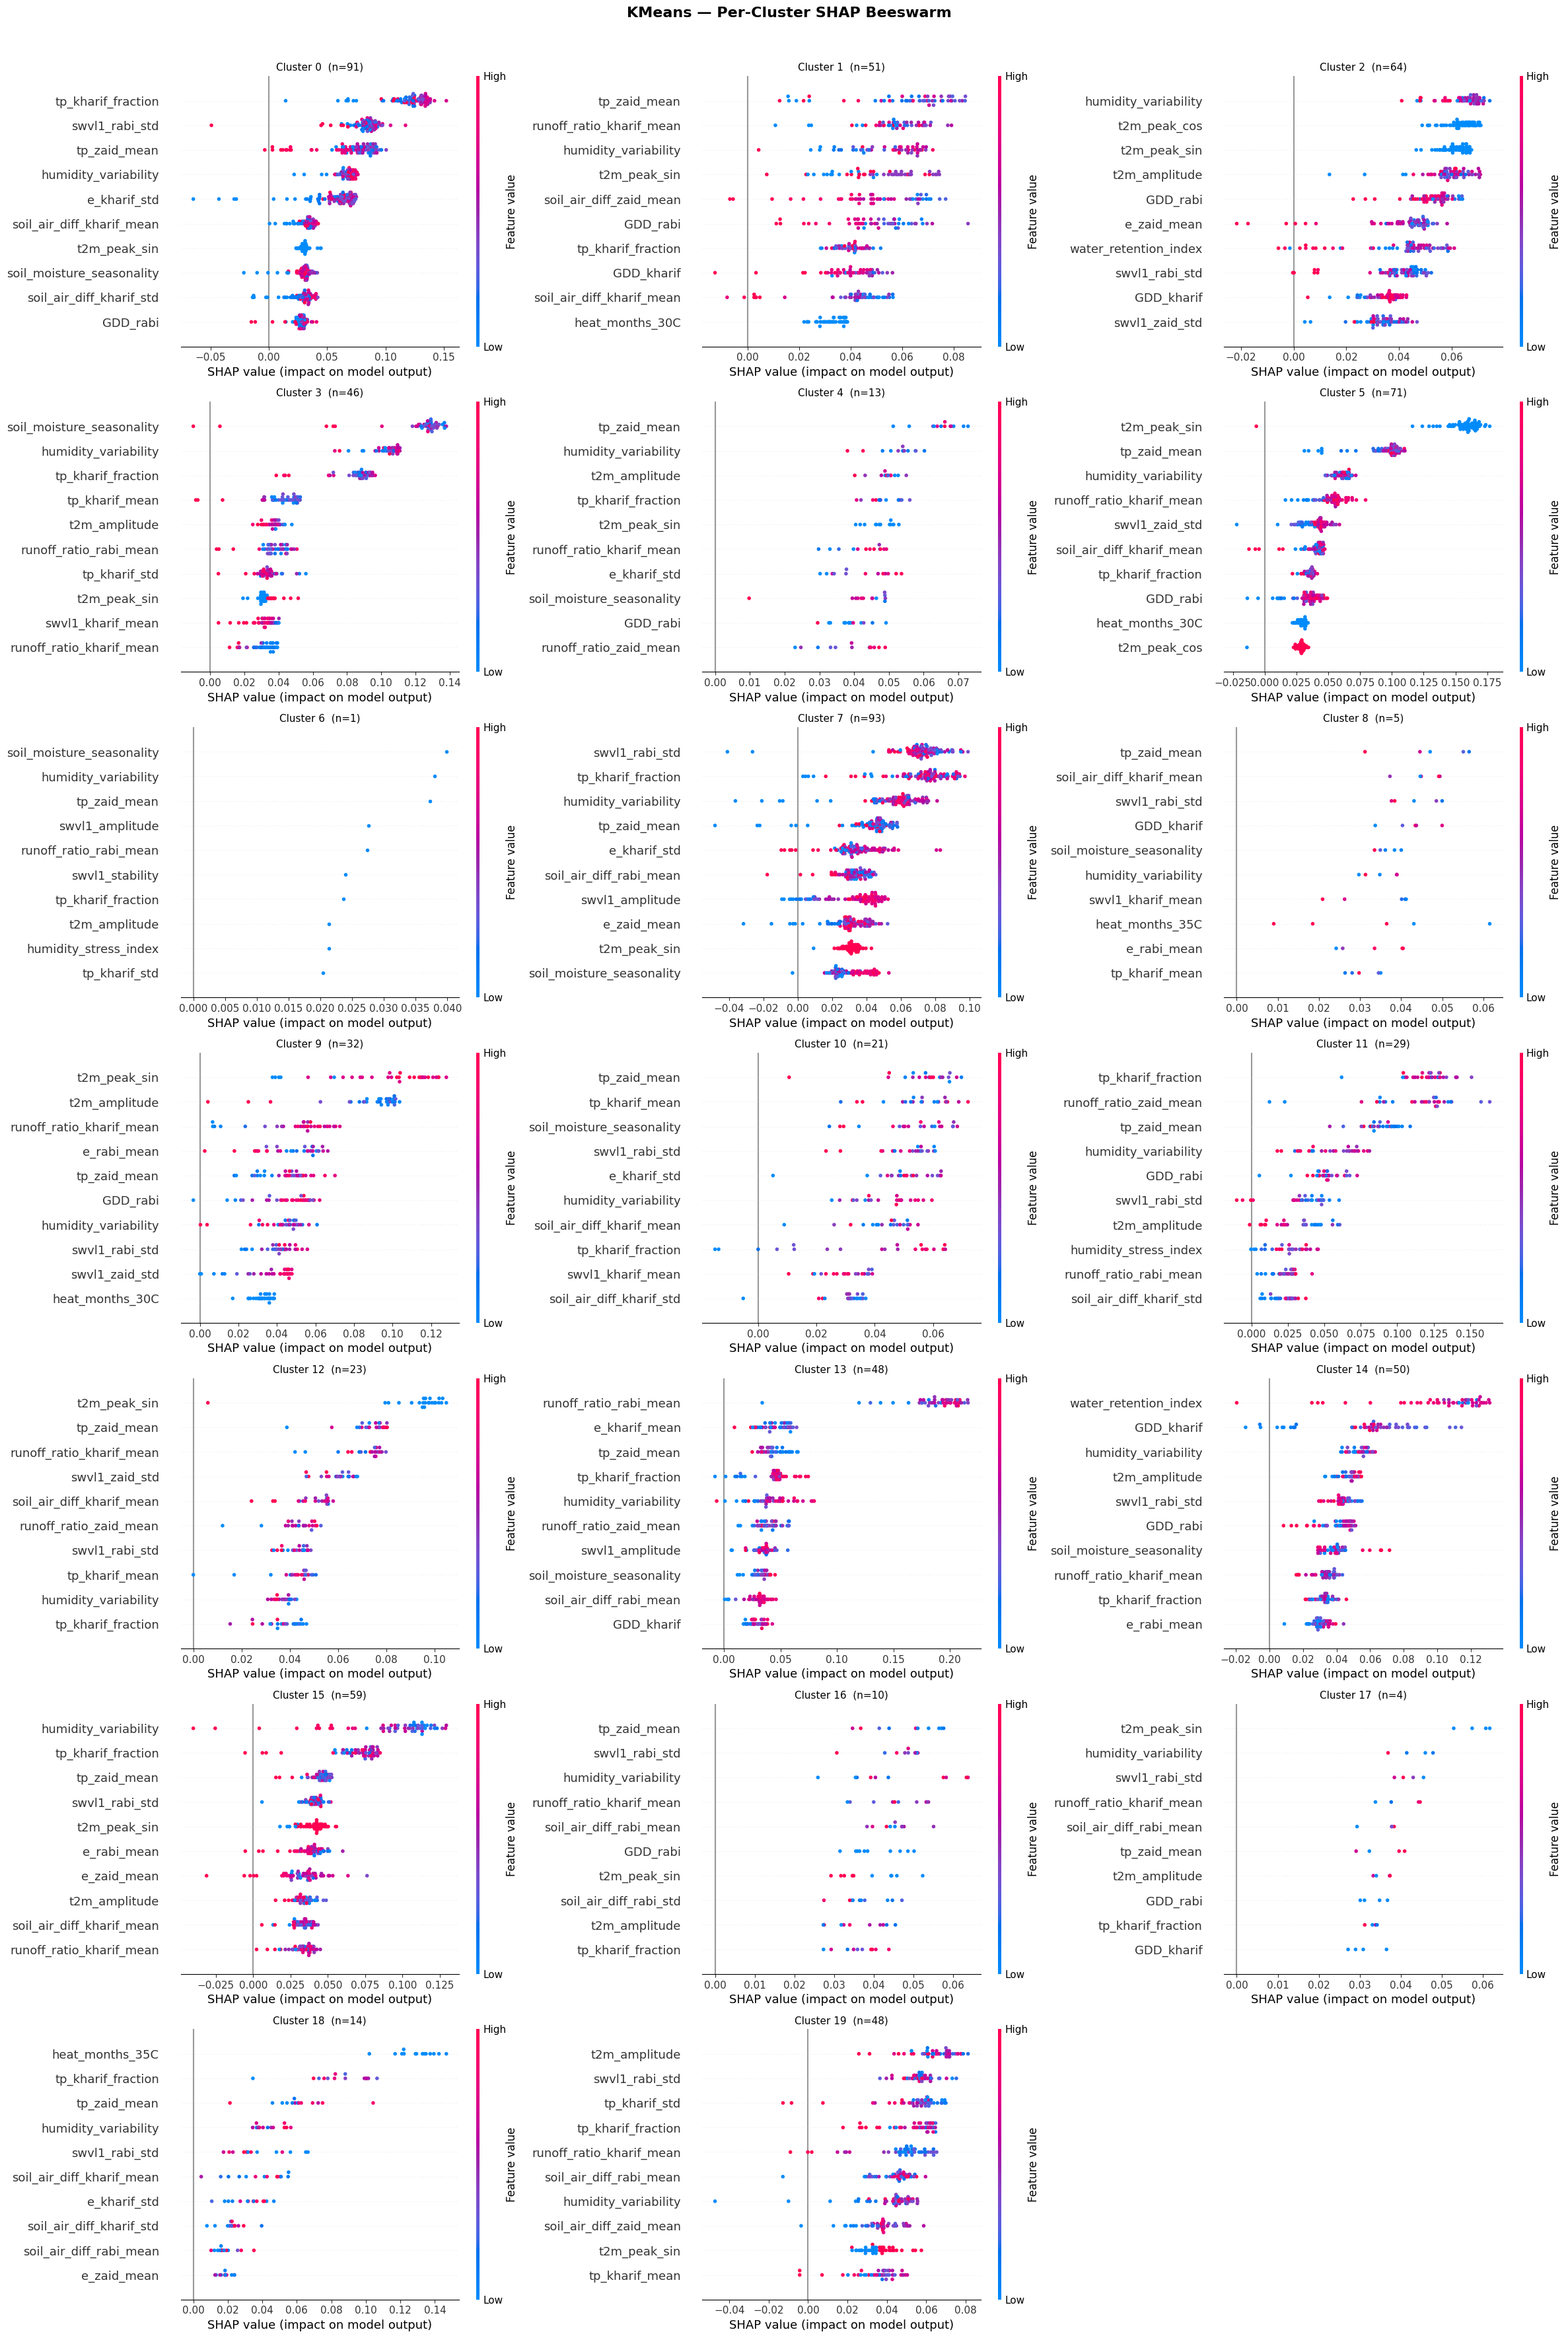

Saved: shap_beeswarm_kmeans.png


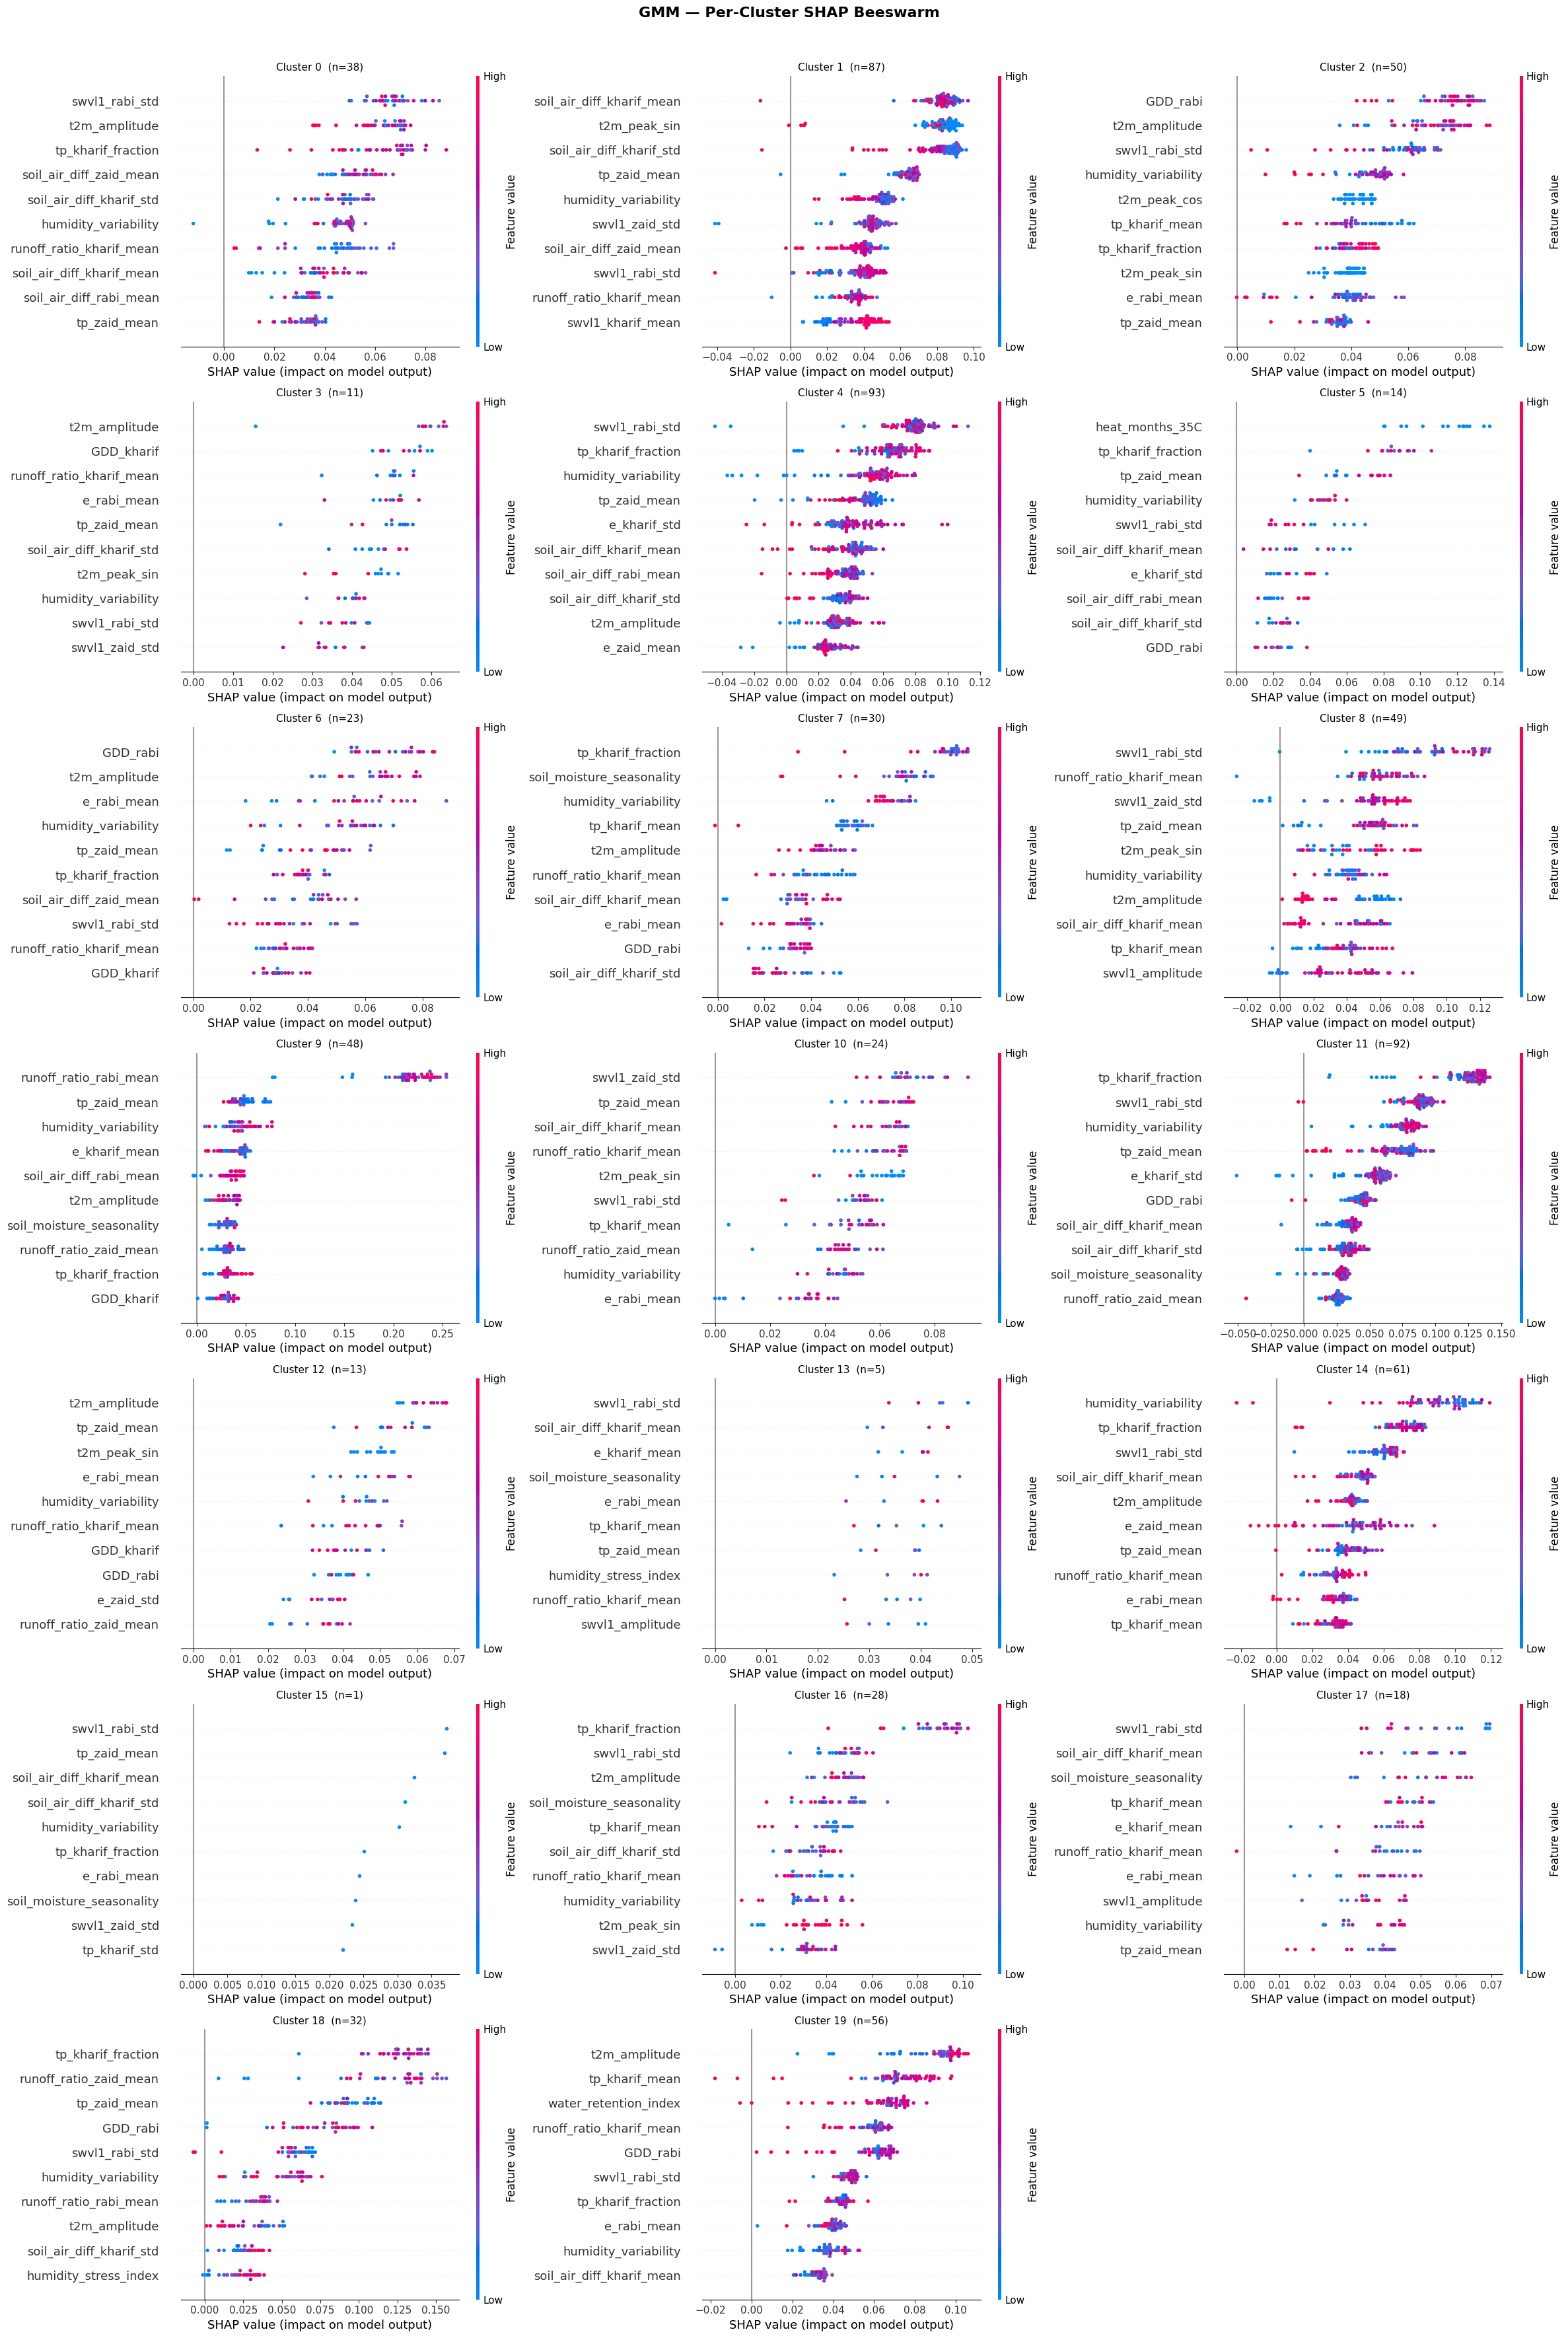

Saved: shap_beeswarm_gmm.png


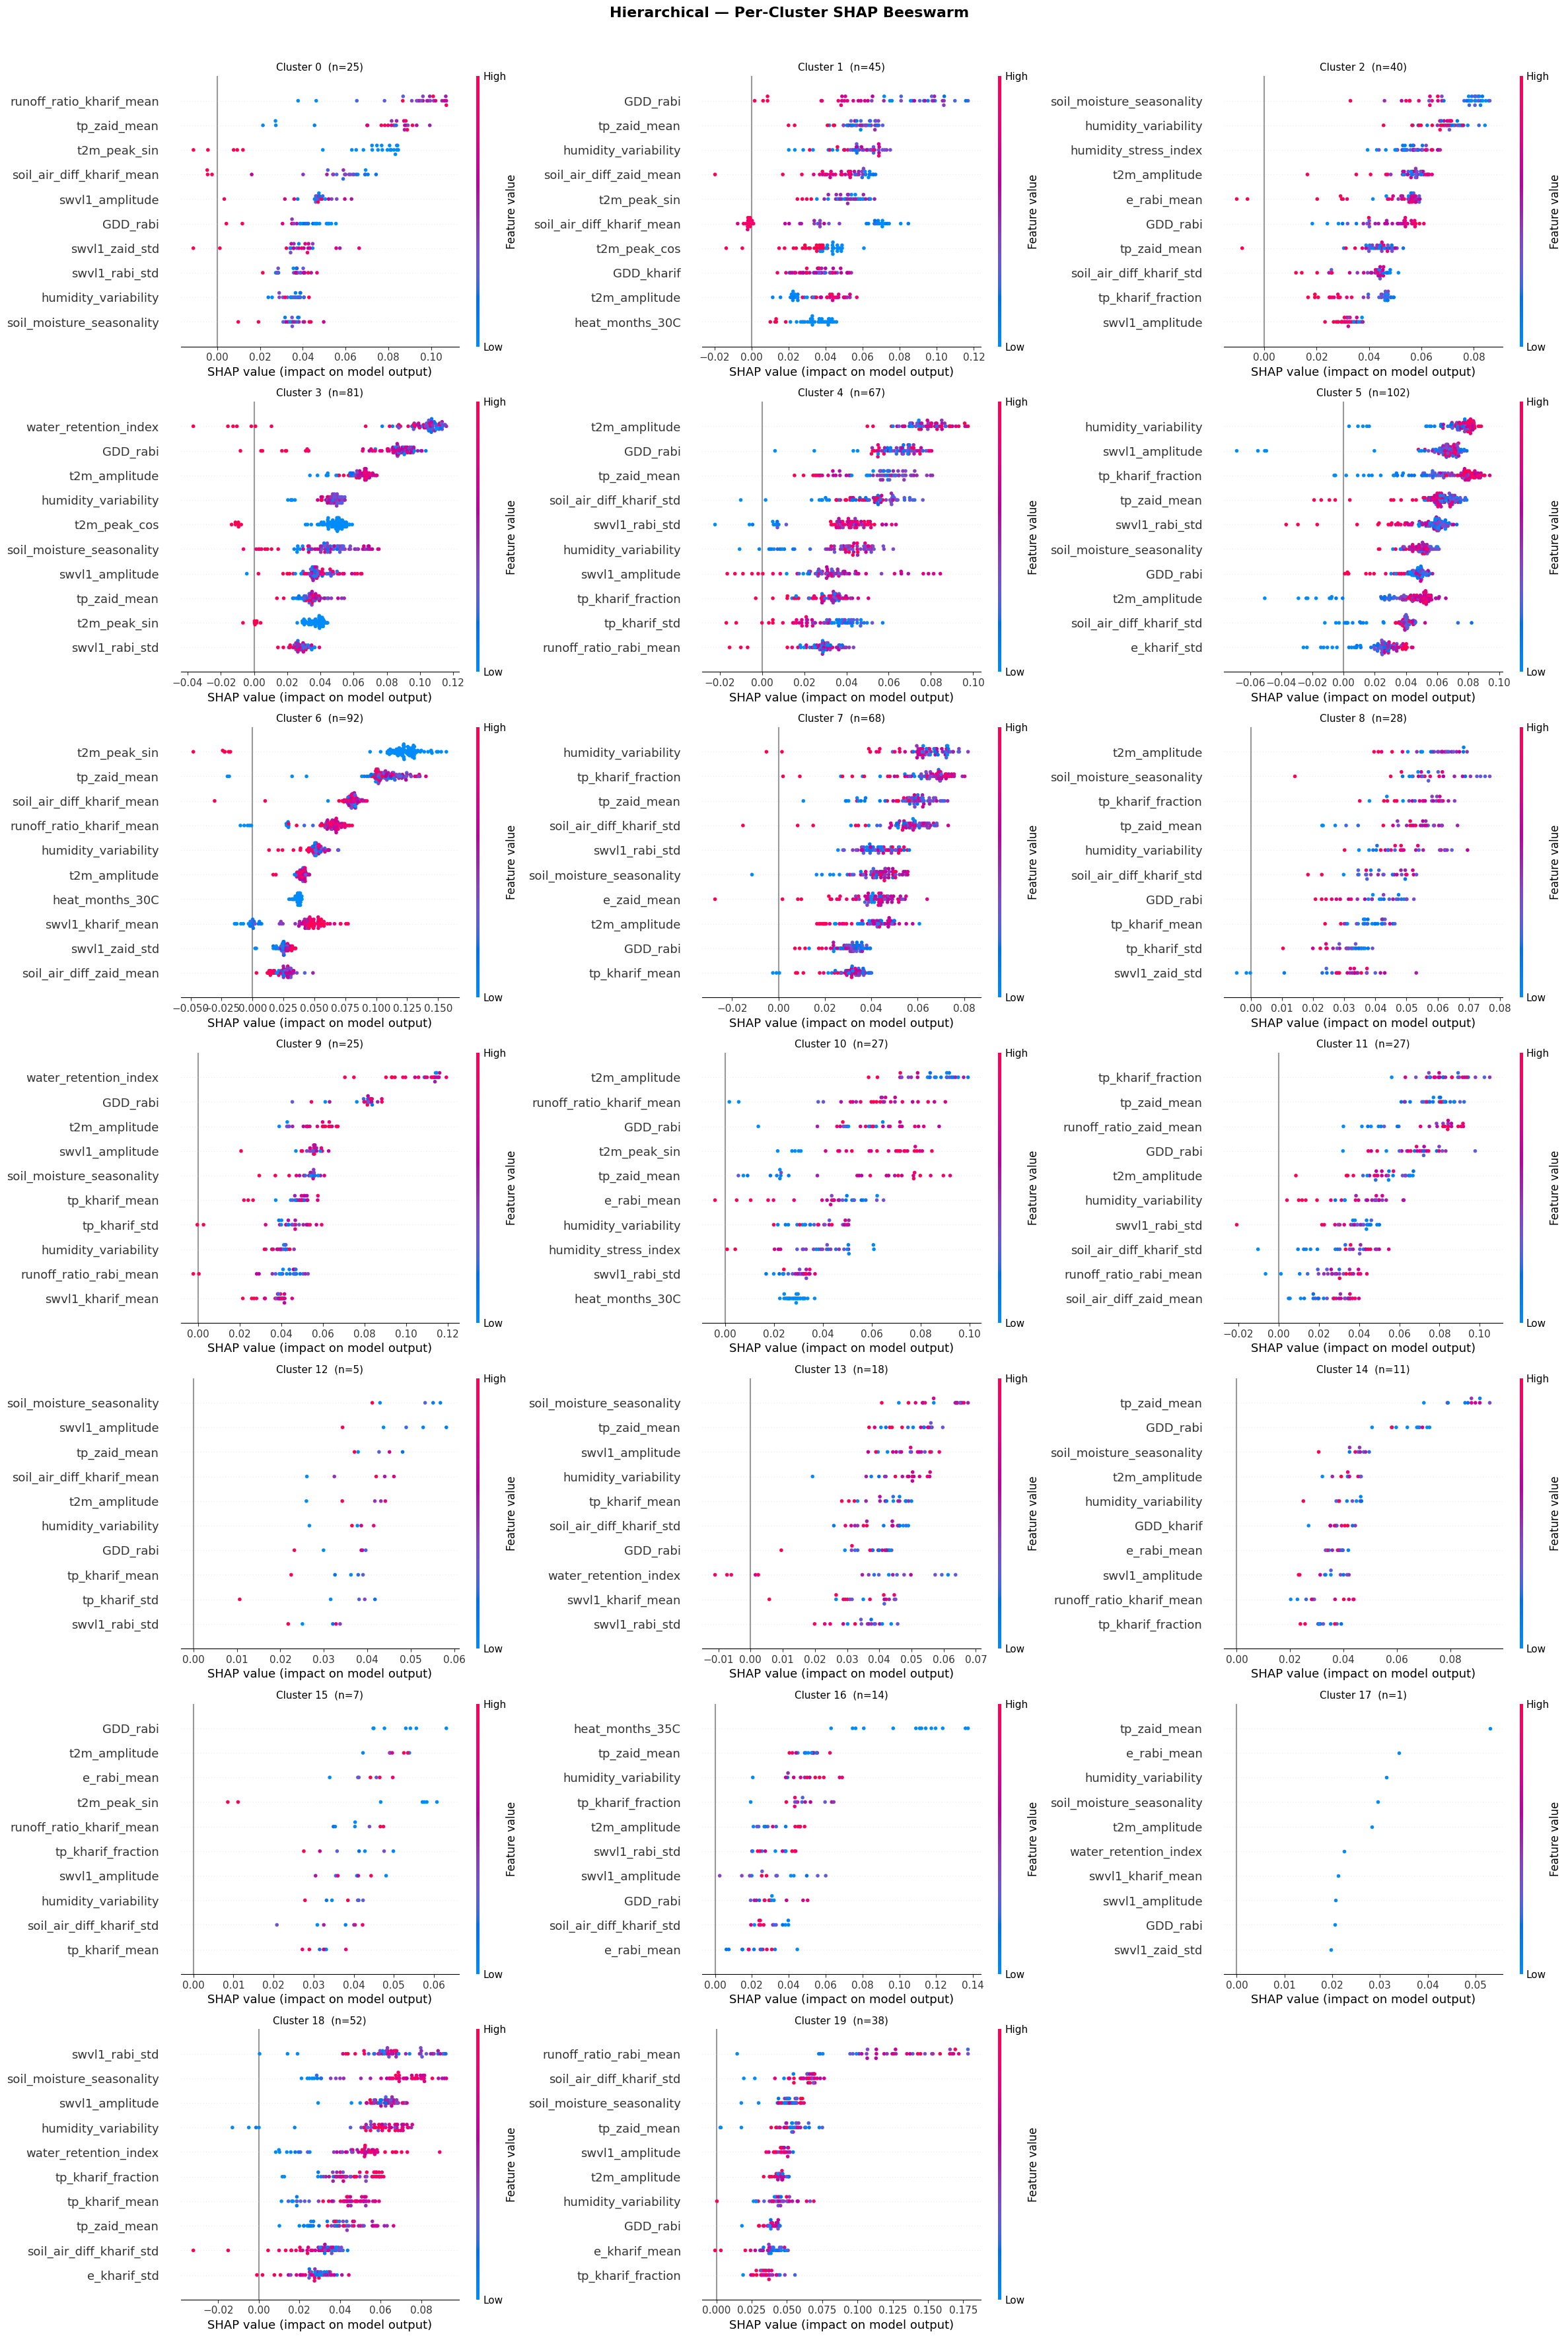

Saved: shap_beeswarm_hierarchical.png


In [124]:
import math

for algo_name, shap_vals, labels in [
    ("KMeans",       shap_kmeans, kmeans_labels),
    ("GMM",          shap_gmm,    gmm_labels),
    ("Hierarchical", shap_hier,   hier_labels),
]:
    unique_clusters = sorted(np.unique(labels))
    n_cols = 3
    n_rows = math.ceil(len(unique_clusters) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 5))
    axes = axes.flatten()
    fig.suptitle(f"{algo_name} — Per-Cluster SHAP Beeswarm", fontsize=16, fontweight='bold', y=1.01)

    for i, cluster_id in enumerate(unique_clusters):
        mask         = labels == cluster_id
        class_shap   = shap_vals[:, :, cluster_id]   # (n_samples, n_features)
        cluster_shap = class_shap[mask, :]
        cluster_X    = X_scaled[mask, :]

        plt.sca(axes[i])
        shap.summary_plot(
            cluster_shap,
            cluster_X,
            feature_names=feature_names,
            show=False,
            plot_size=None,
            max_display=10         # top 10 features per cluster to keep it readable
        )
        axes[i].set_title(f"Cluster {cluster_id}  (n={mask.sum()})", fontsize=11)

    # hide unused subplots
    for j in range(len(unique_clusters), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_beeswarm_{algo_name.lower()}.png")

C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\1692706992.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap    = cm.get_cmap('tab20', n_clusters)


[KMeans] Matched: 773 / 785


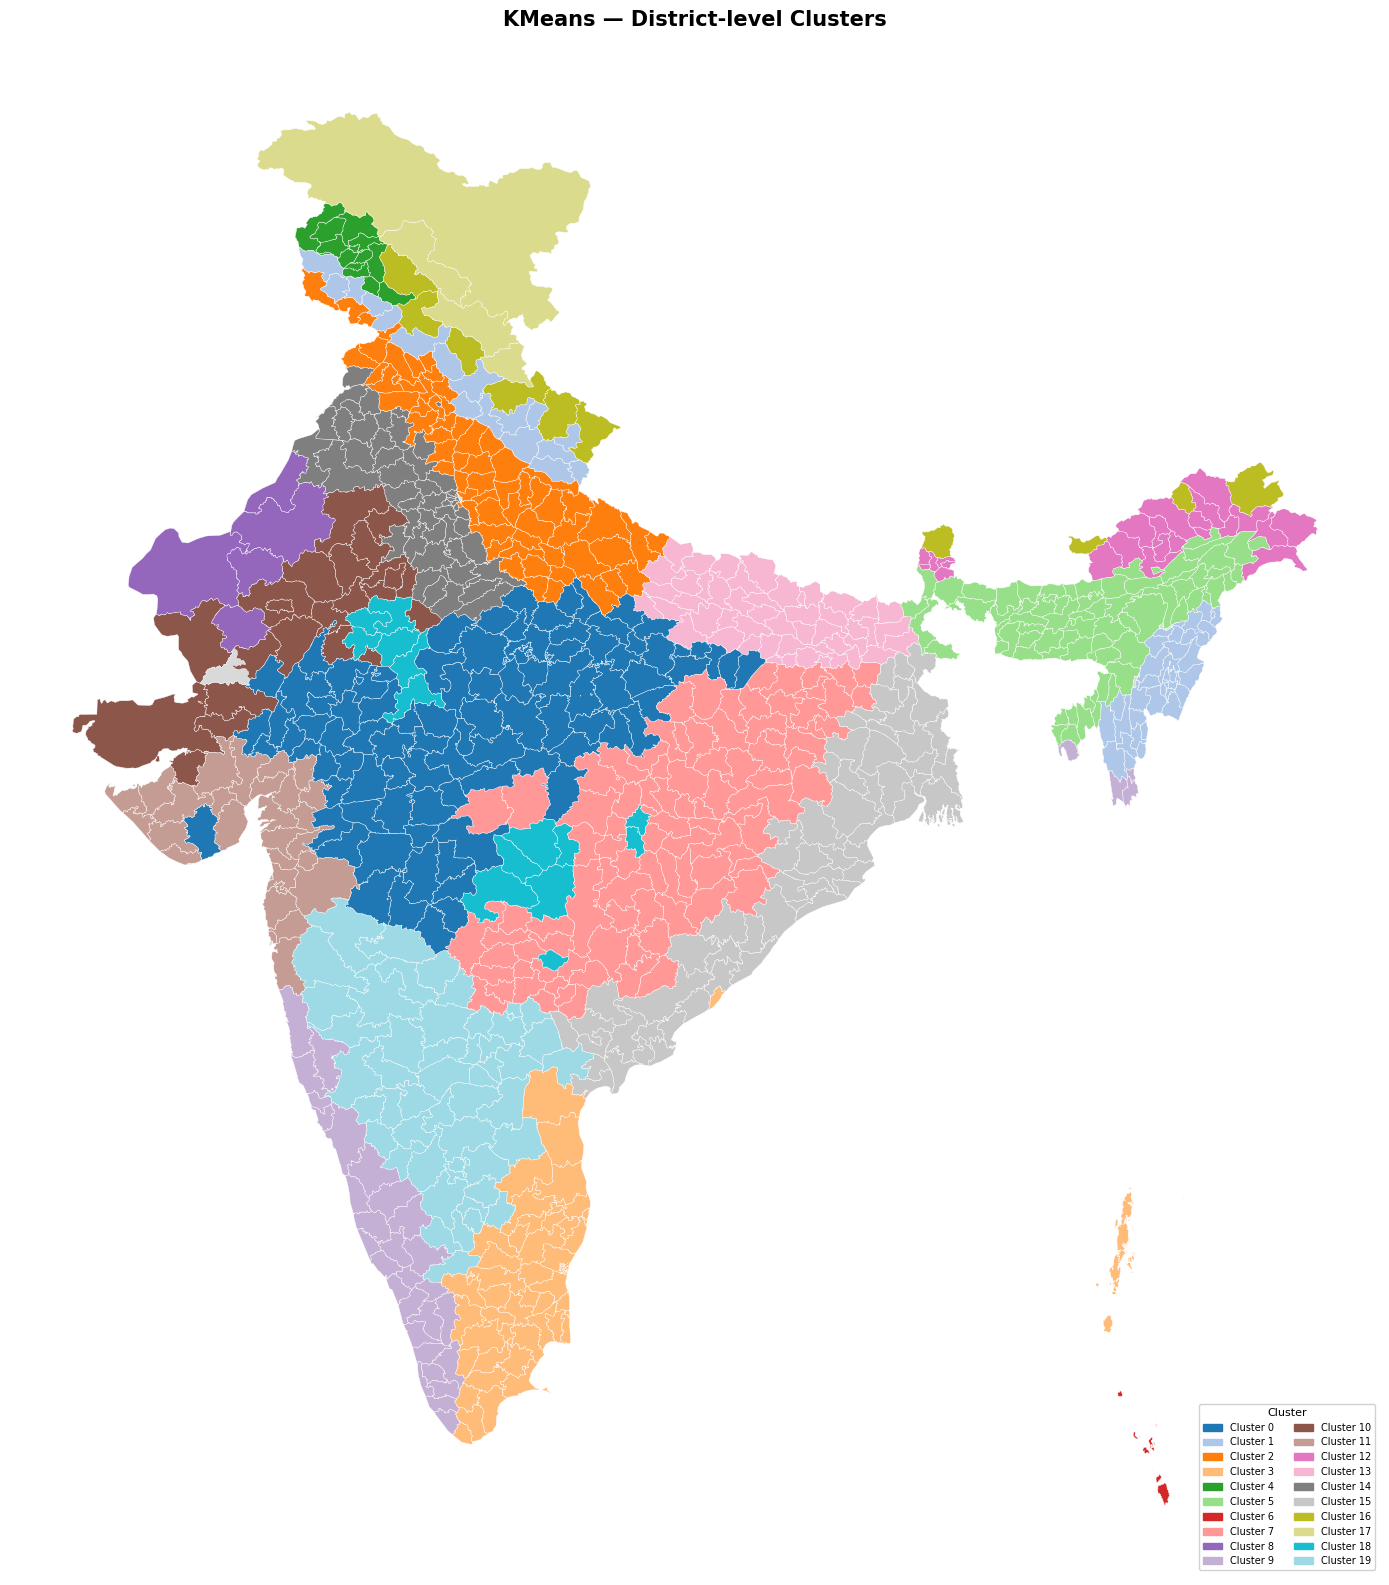

Saved: choropleth_kmeans.png
[GMM] Matched: 773 / 785


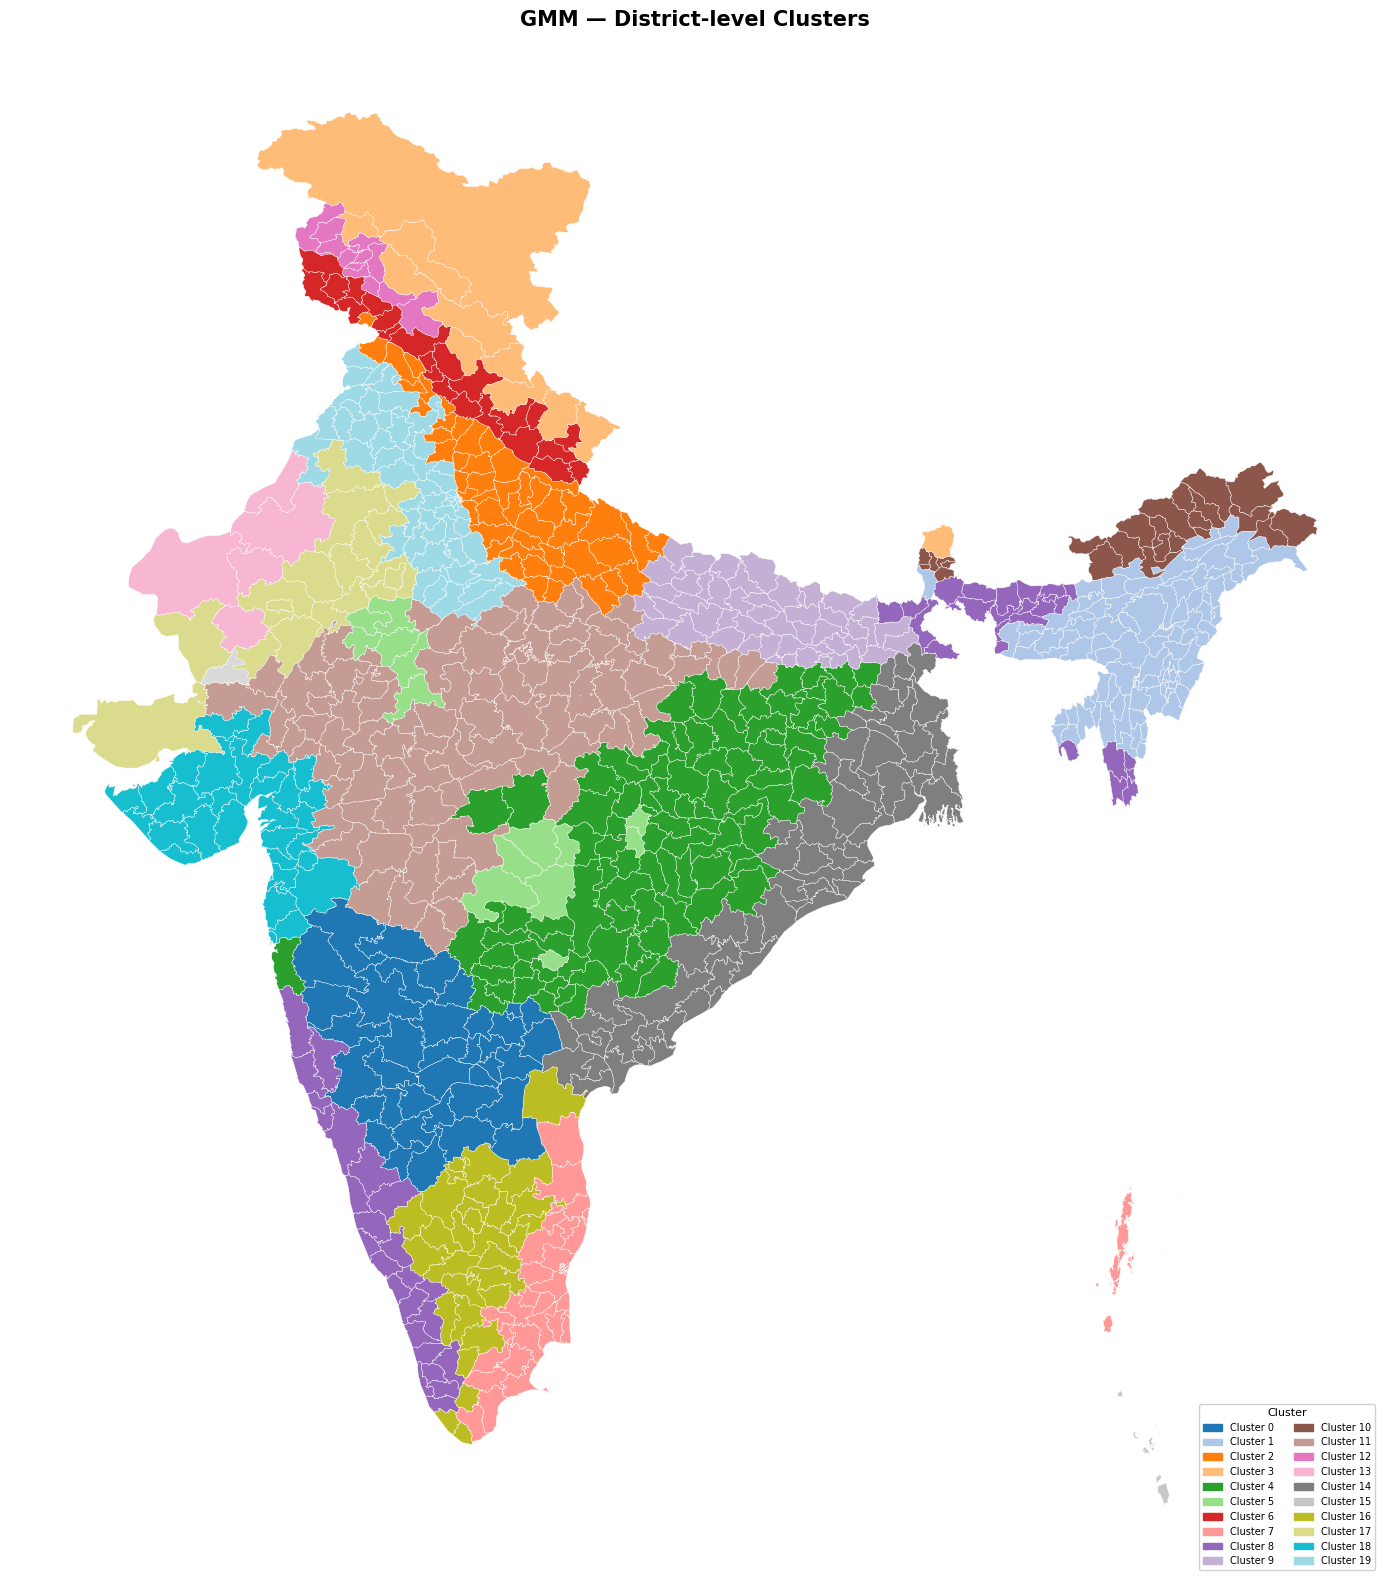

Saved: choropleth_gmm.png
[Hierarchical] Matched: 773 / 785


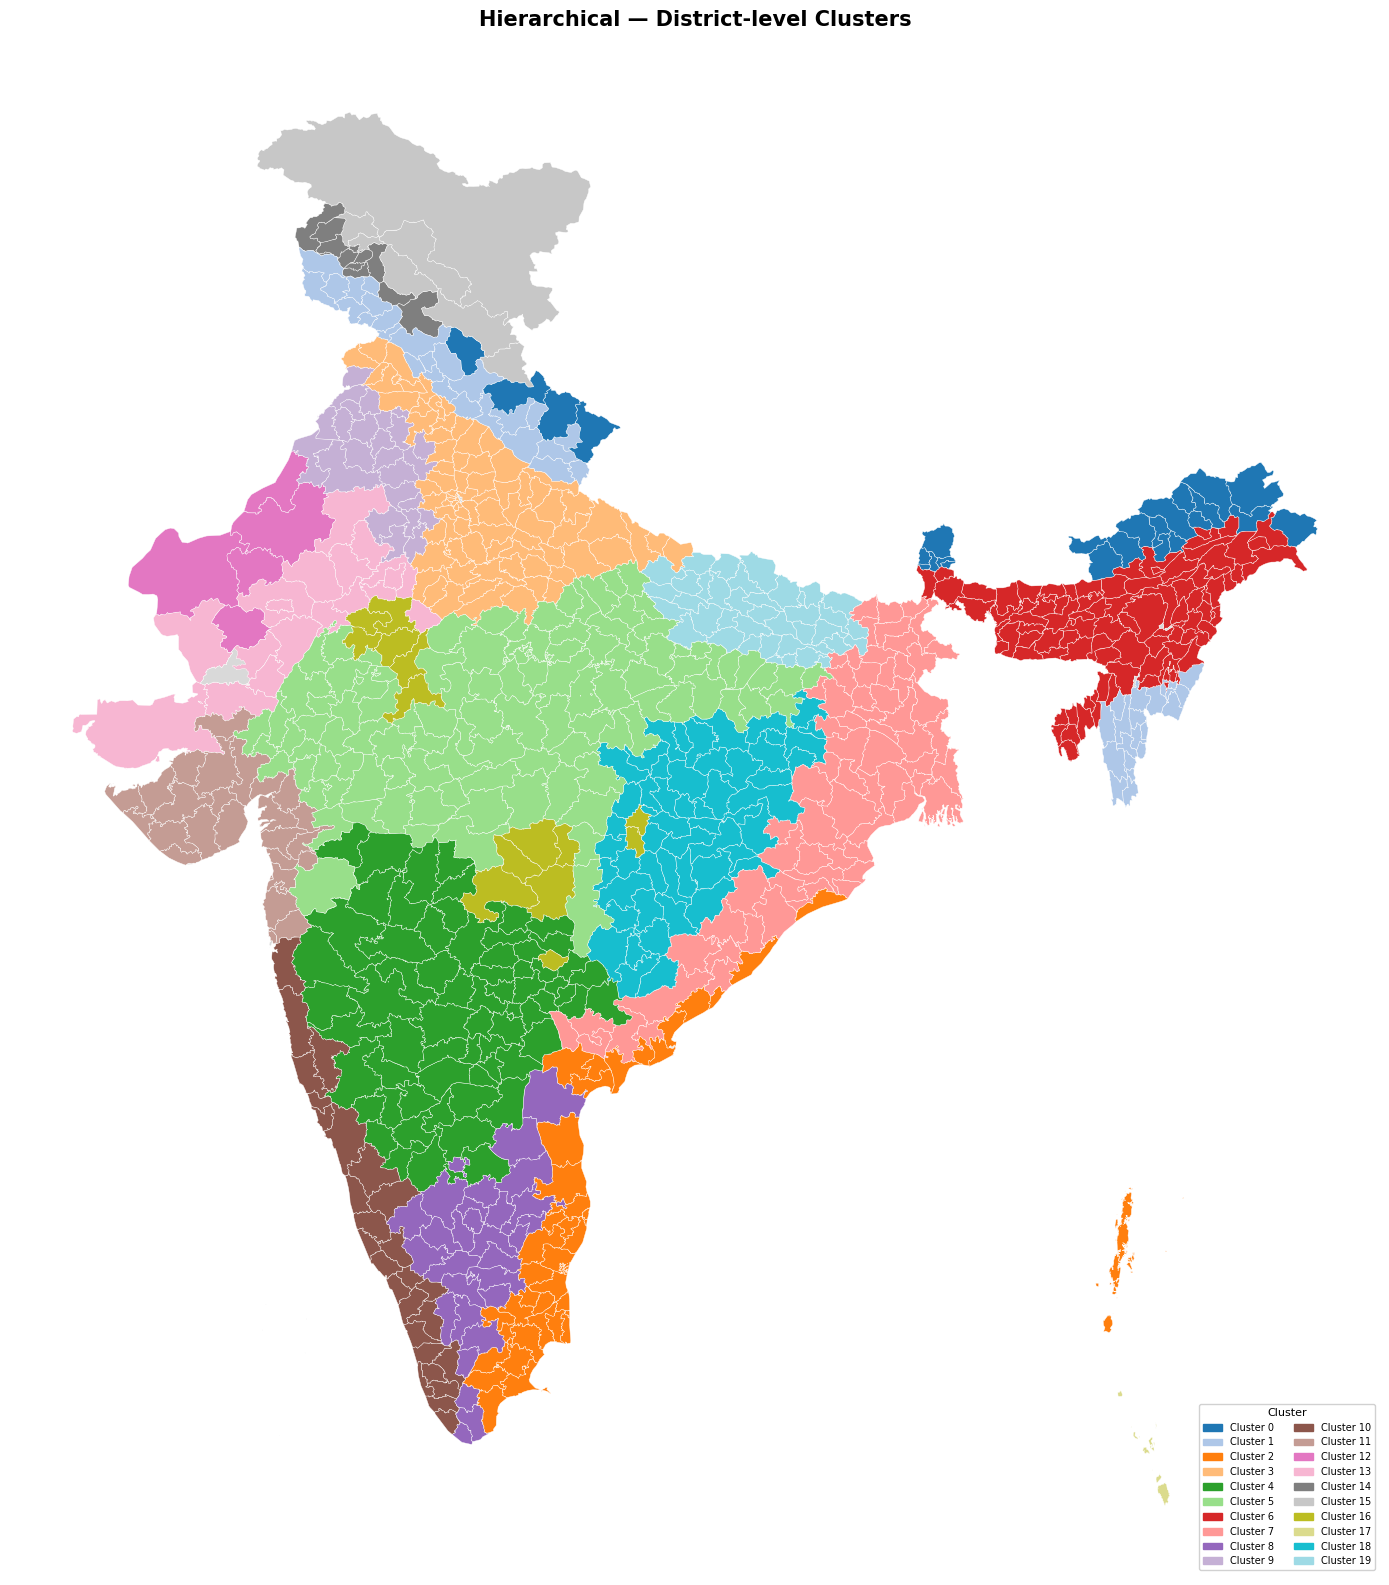

Saved: choropleth_hierarchical.png


In [125]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
import requests, io

geojson_url = "https://raw.githubusercontent.com/saketlab/bharatviz/refs/heads/main/public/India_LGD_districts.geojson"
gdf = gpd.read_file(io.BytesIO(requests.get(geojson_url).content))

# Normalize join keys
gdf['district_norm'] = gdf['district_name'].str.strip().str.title()
gdf['state_norm']    = gdf['state_name'].str.strip().str.title()

# Color palette — one color per cluster
cmap    = cm.get_cmap('tab20', n_clusters)
colors  = {i: cmap(i) for i in range(n_clusters)}

for algo_name, df in [
    ("KMeans",       kmeans_df),
    ("GMM",          gmm_df),
    ("Hierarchical", hier_df),
]:
    plot_df = df[['state', 'district', 'cluster']].copy()
    plot_df['district_norm'] = plot_df['district'].str.strip().str.title()
    plot_df['state_norm']    = plot_df['state'].str.strip().str.title()

    # Merge cluster info into geodataframe
    merged = gdf.merge(
        plot_df[['state_norm', 'district_norm', 'cluster']],
        on=['state_norm', 'district_norm'],
        how='left'
    )

    matched = merged['cluster'].notna().sum()
    print(f"[{algo_name}] Matched: {matched} / {len(gdf)}")

    merged['color'] = merged['cluster'].apply(
        lambda c: colors[int(c)] if pd.notna(c) else (0.85, 0.85, 0.85, 1)  # grey for unmatched
    )

    fig, ax = plt.subplots(1, 1, figsize=(14, 16))

    merged.plot(
        ax=ax,
        color=merged['color'].tolist(),
        edgecolor='white',
        linewidth=0.3
    )

    # Legend
    patches = [
        mpatches.Patch(color=colors[i], label=f'Cluster {i}')
        for i in range(n_clusters)
    ]
    ax.legend(
        handles=patches,
        loc='lower right',
        ncol=2,
        fontsize=7,
        title='Cluster',
        title_fontsize=8,
        framealpha=0.9
    )

    ax.set_title(f"{algo_name} — District-level Clusters", fontsize=15, fontweight='bold', pad=12)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"choropleth_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: choropleth_{algo_name.lower()}.png")

In [126]:
comparison_df['kmeans_cluster']  = kmeans_df['cluster'].values
comparison_df['gmm_cluster']     = gmm_df['cluster'].values
comparison_df['hier_cluster']    = hier_df['cluster'].values

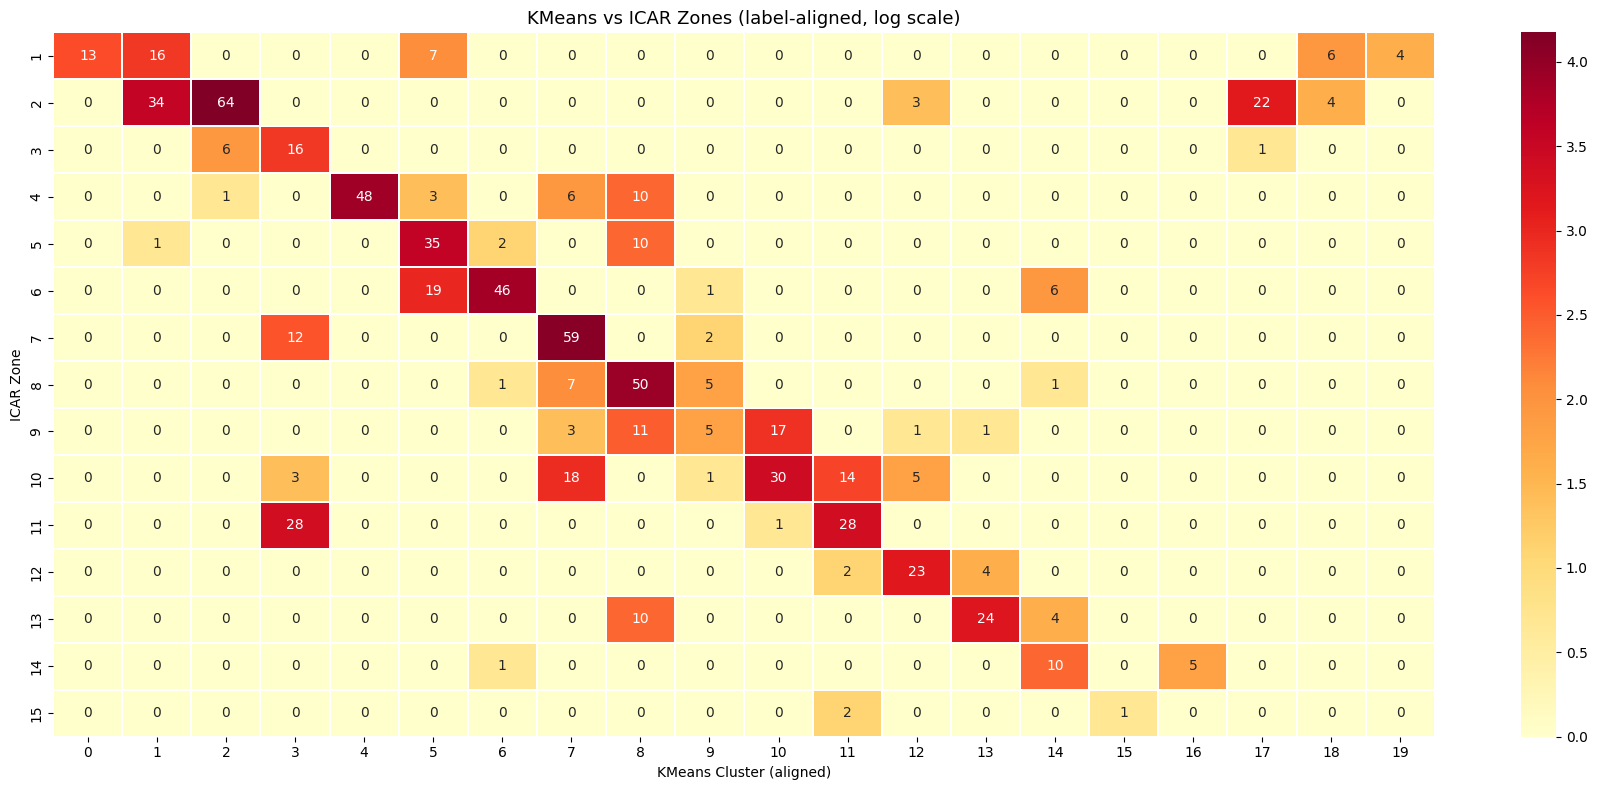

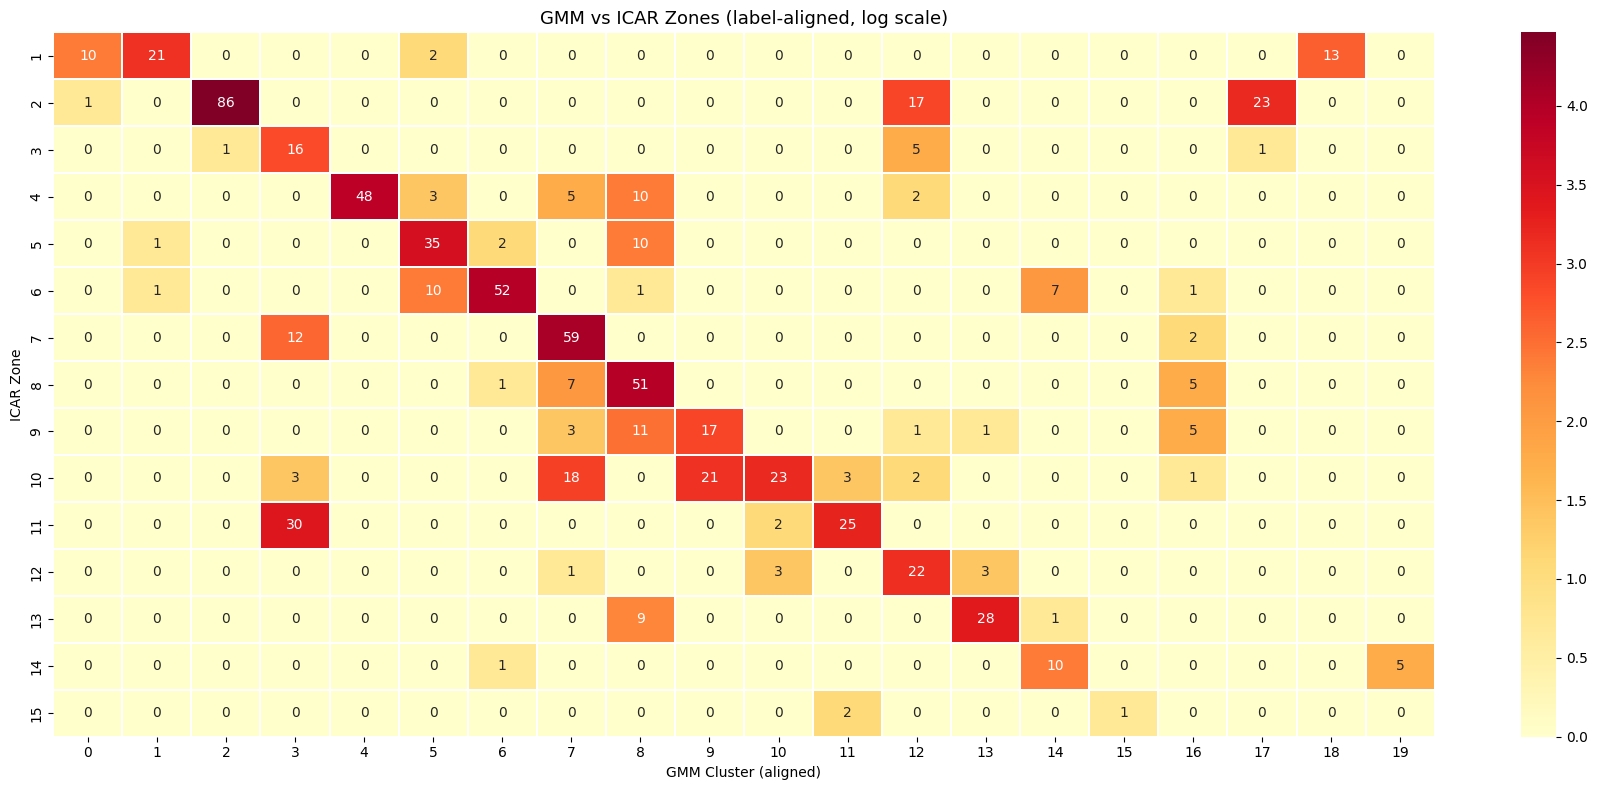

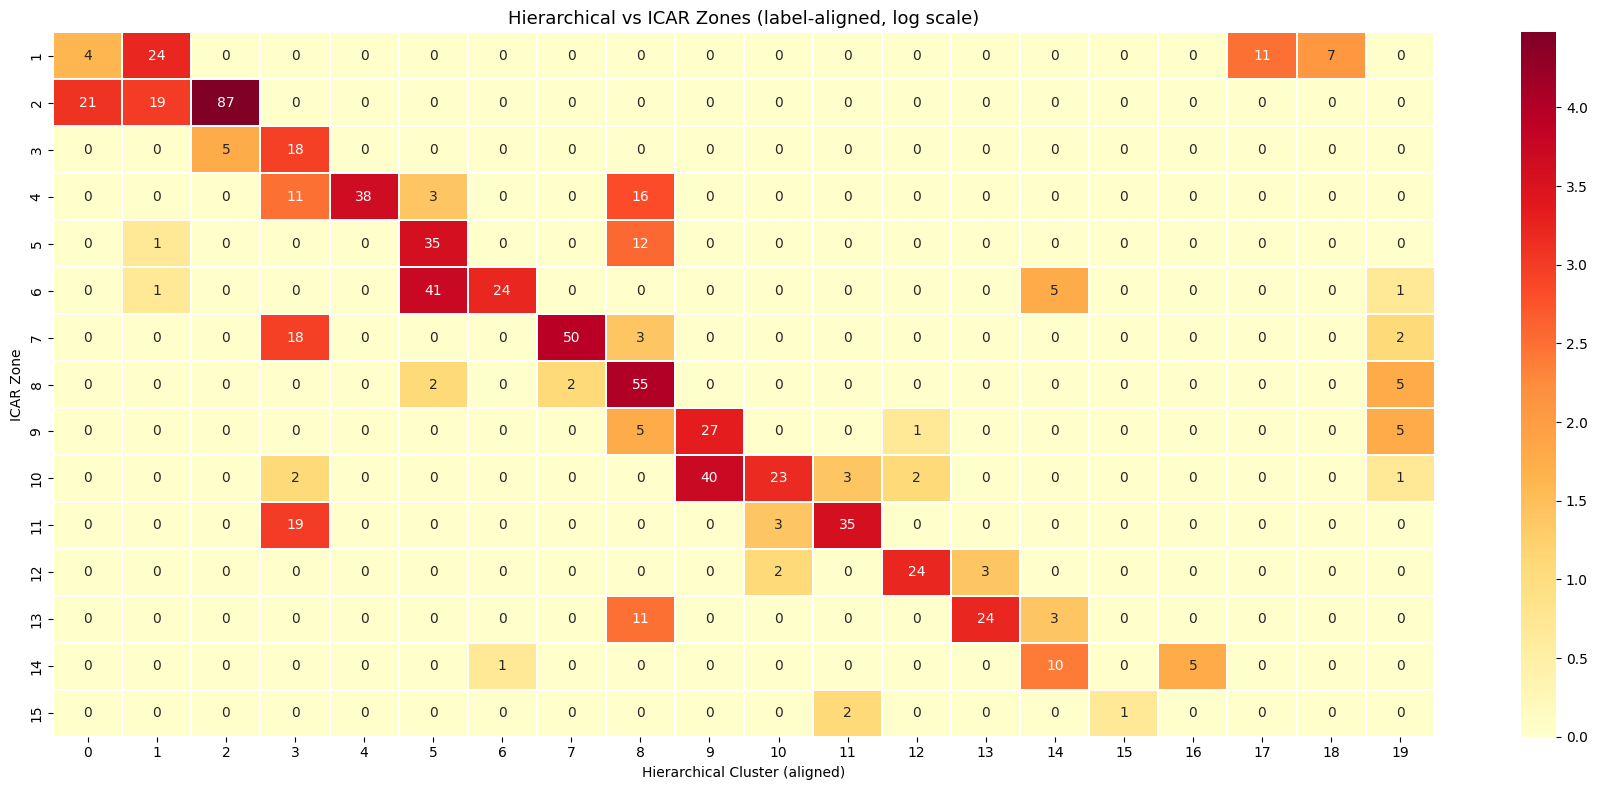

In [127]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import seaborn as sns

def align_labels(true_labels, pred_labels):
    """Remap cluster IDs to best match reference labels via Hungarian algorithm"""
    # true may have 15 classes, pred has 18 — pad to square
    n = max(true_labels.max() + 1, pred_labels.max() + 1)
    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(n)))
    # maximize overlap = minimize negative
    row_ind, col_ind = linear_sum_assignment(-cm)
    # col_ind[i] = which cluster maps to ICAR zone i
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    remapped = np.array([mapping.get(l, -1) for l in pred_labels])
    return remapped

# Align all three
kmeans_aligned = align_labels(comparison_df['label'].values, kmeans_df['cluster'].values)
gmm_aligned    = align_labels(comparison_df['label'].values, gmm_df['cluster'].values)
hier_aligned   = align_labels(comparison_df['label'].values, hier_df['cluster'].values)

for algo_name, aligned in [('KMeans', kmeans_aligned), ('GMM', gmm_aligned), ('Hierarchical', hier_aligned)]:
    ct = pd.crosstab(
        comparison_df['label'],
        aligned,
        rownames=['ICAR Zone'],
        colnames=[f'{algo_name} Cluster (aligned)']
    )

    plt.figure(figsize=(18, 8))
    sns.heatmap(
        np.log1p(ct),          # log scale — log1p avoids log(0)
        annot=ct.values,       # show raw counts, not log values
        fmt='d',
        cmap='YlOrRd',
        linewidths=0.3
    )
    plt.title(f"{algo_name} vs ICAR Zones (label-aligned, log scale)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"icar_vs_{algo_name.lower()}_aligned.png", dpi=150, bbox_inches='tight')
    plt.show()

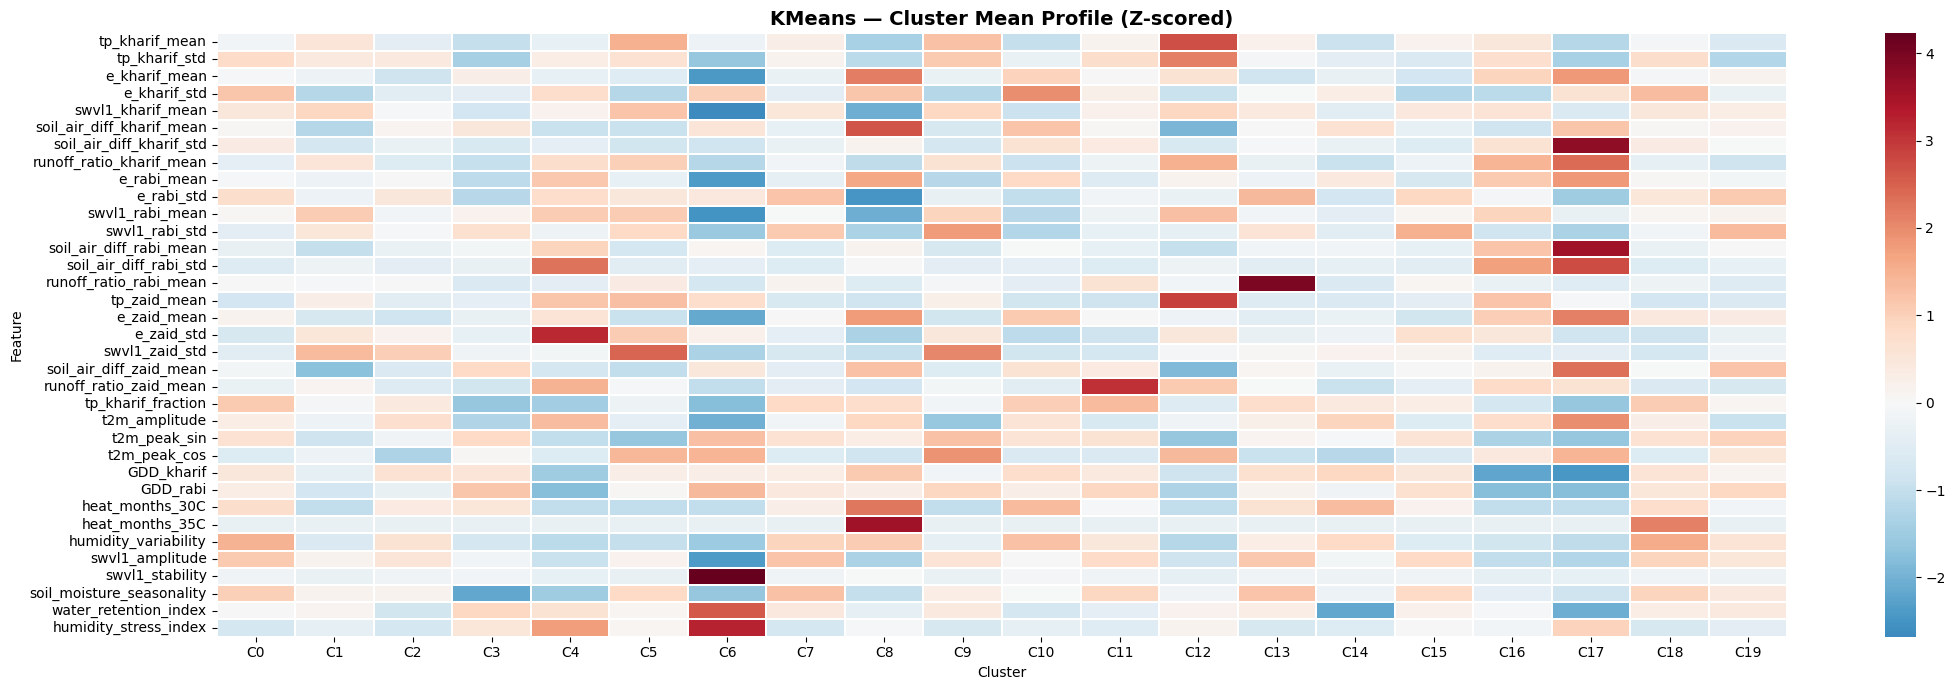

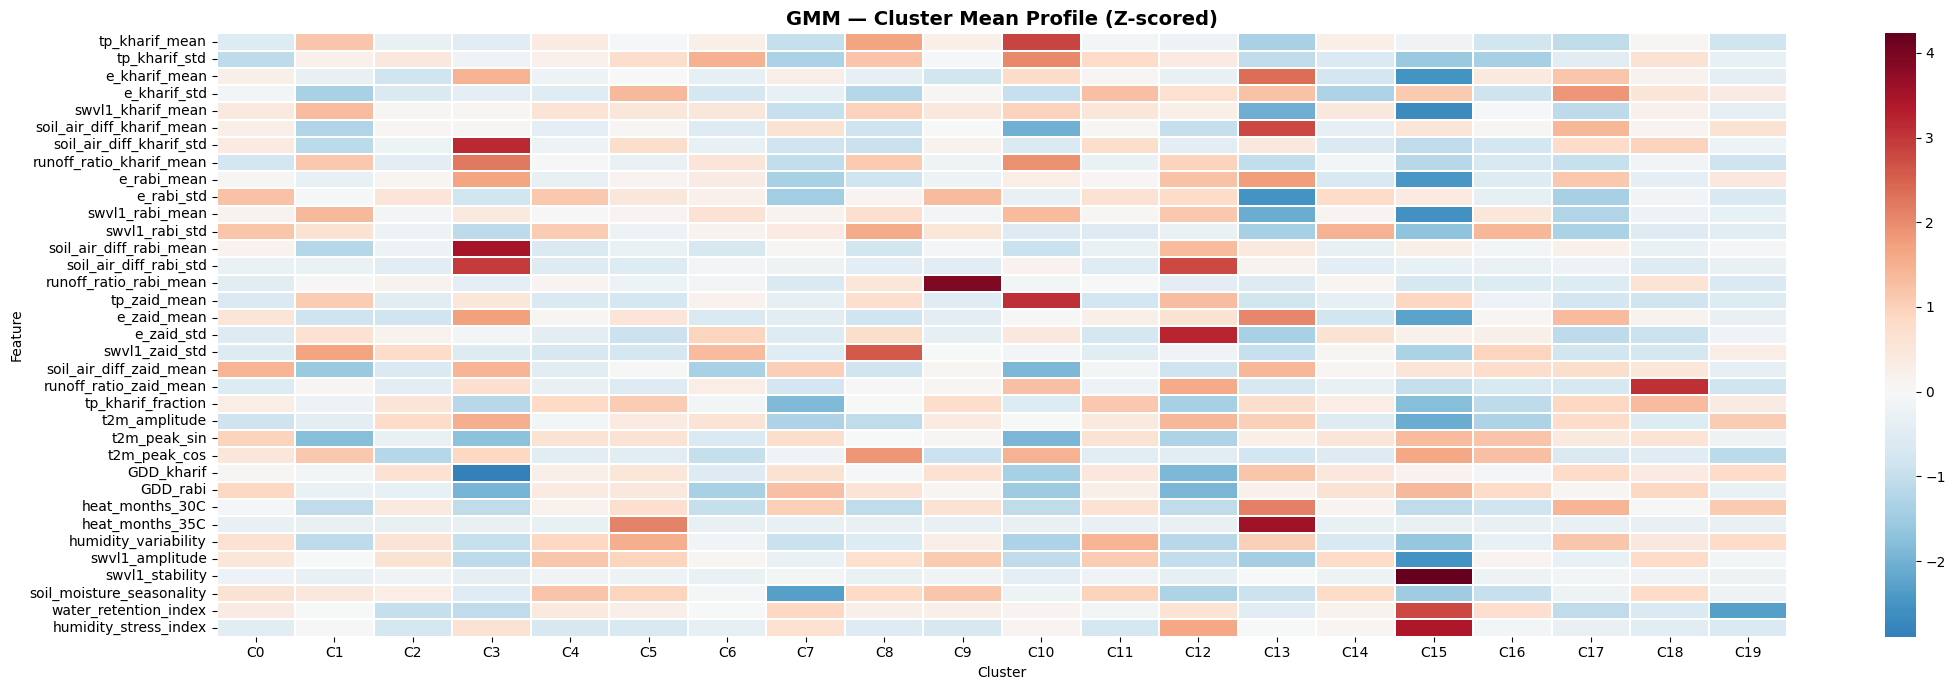

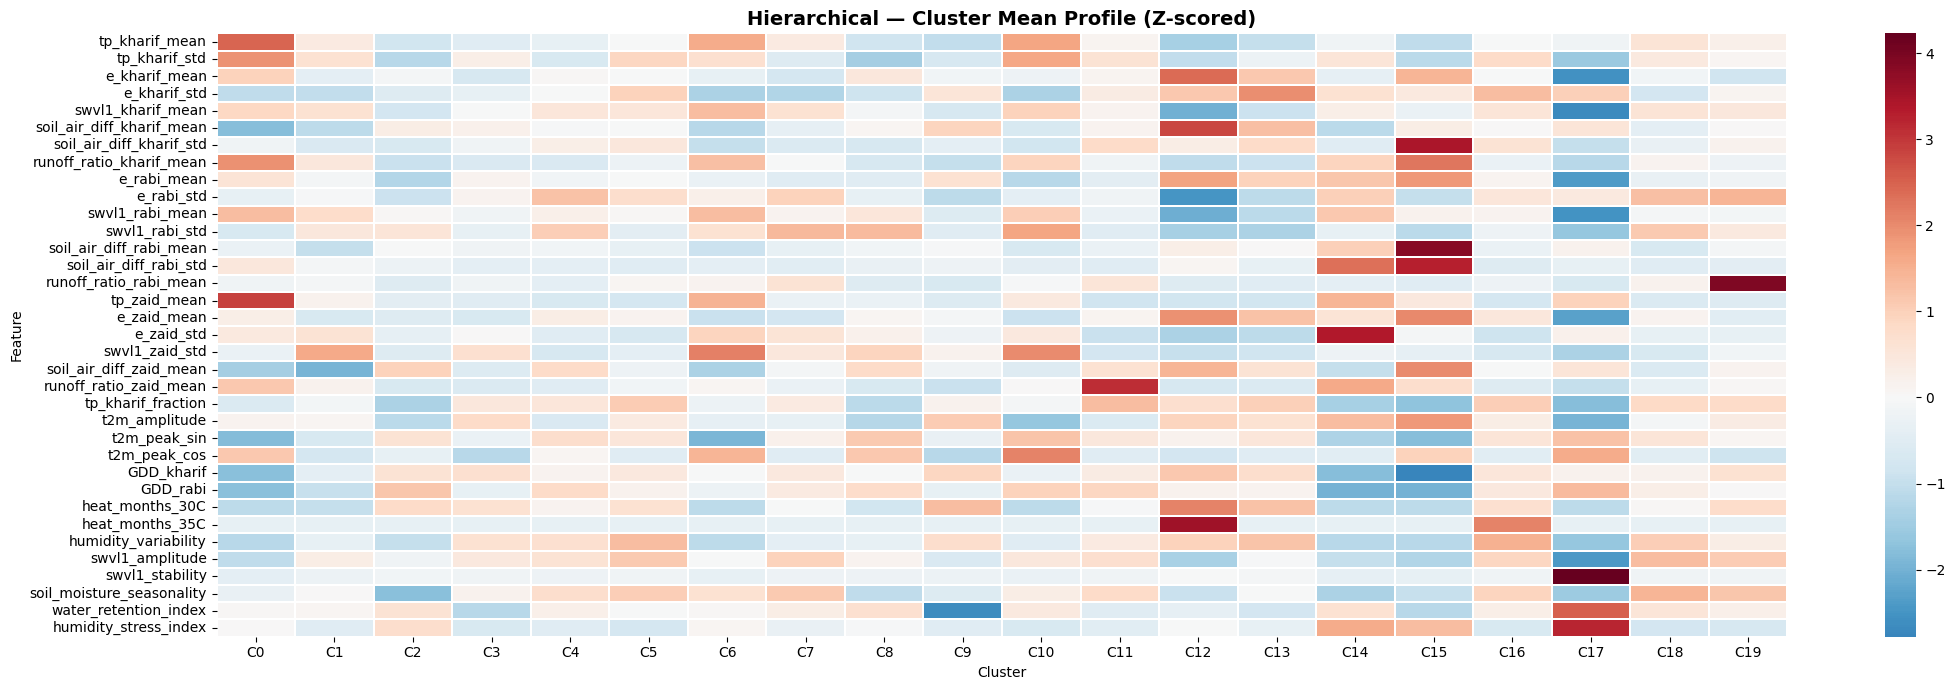

C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab

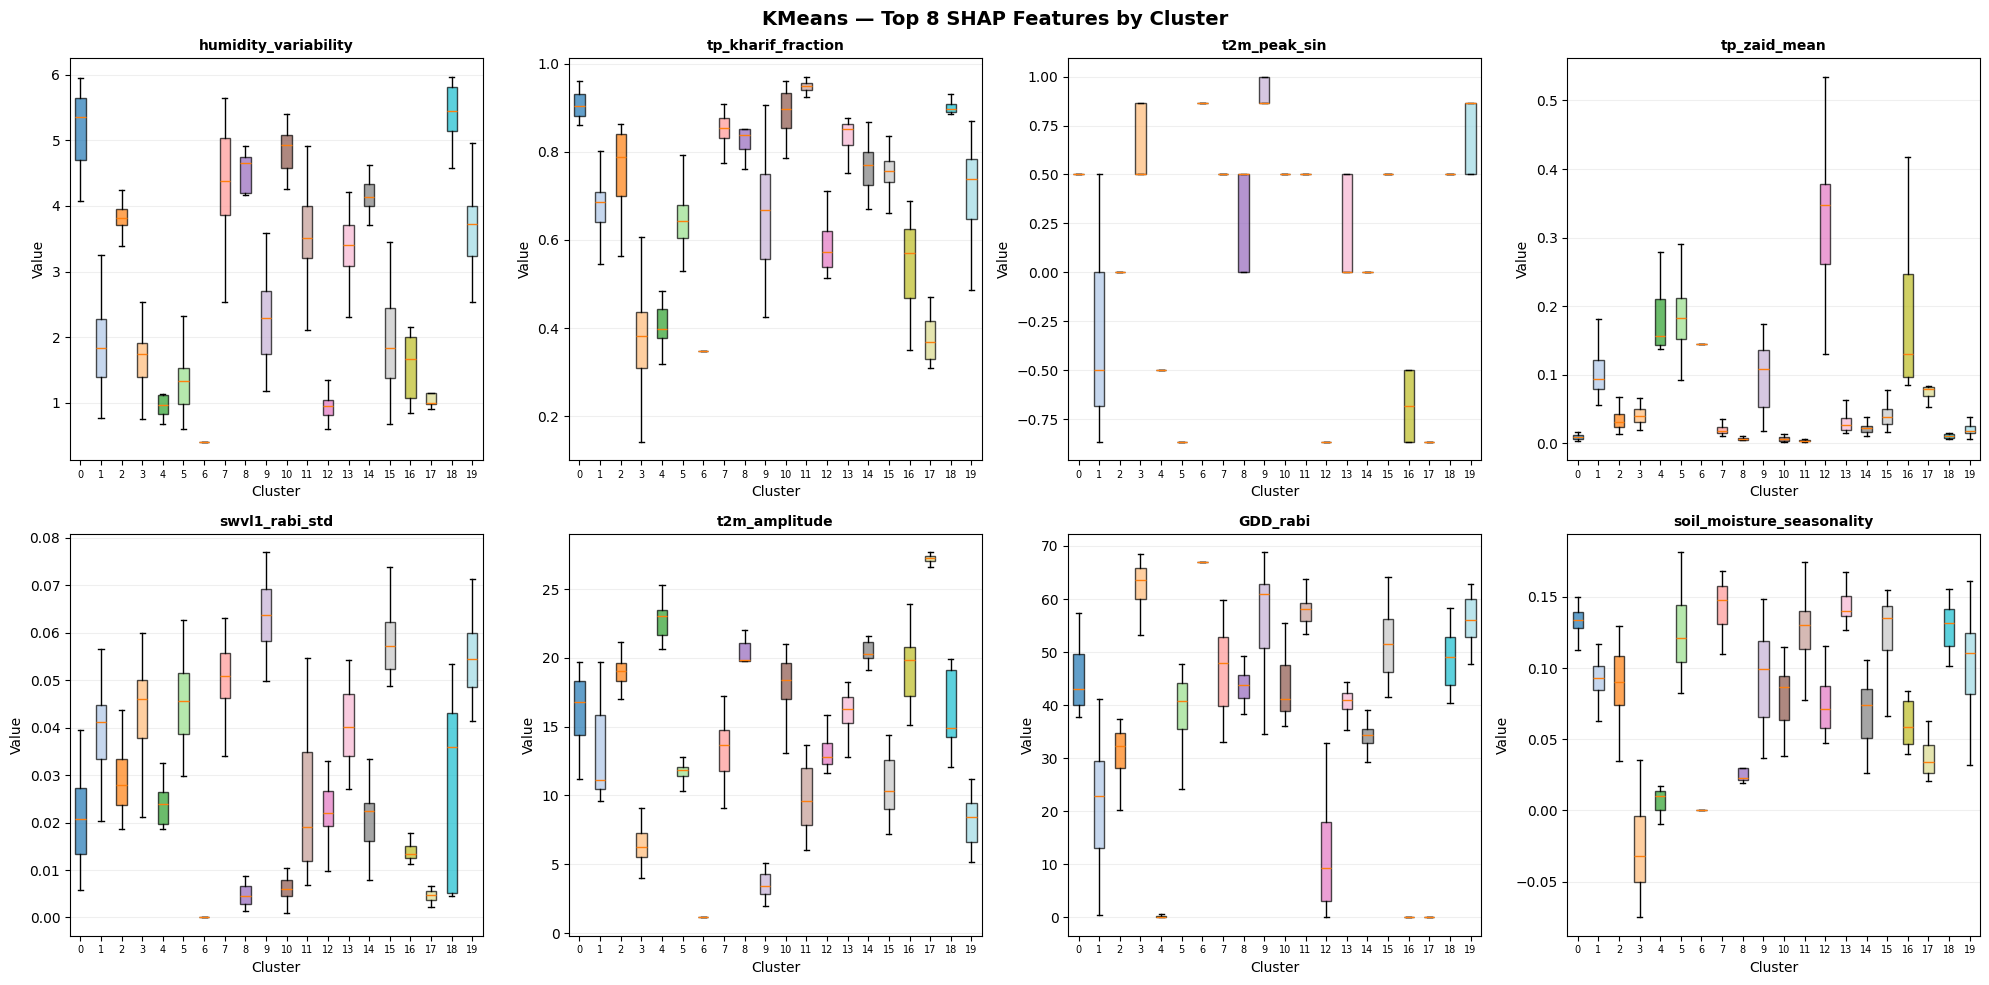

C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab

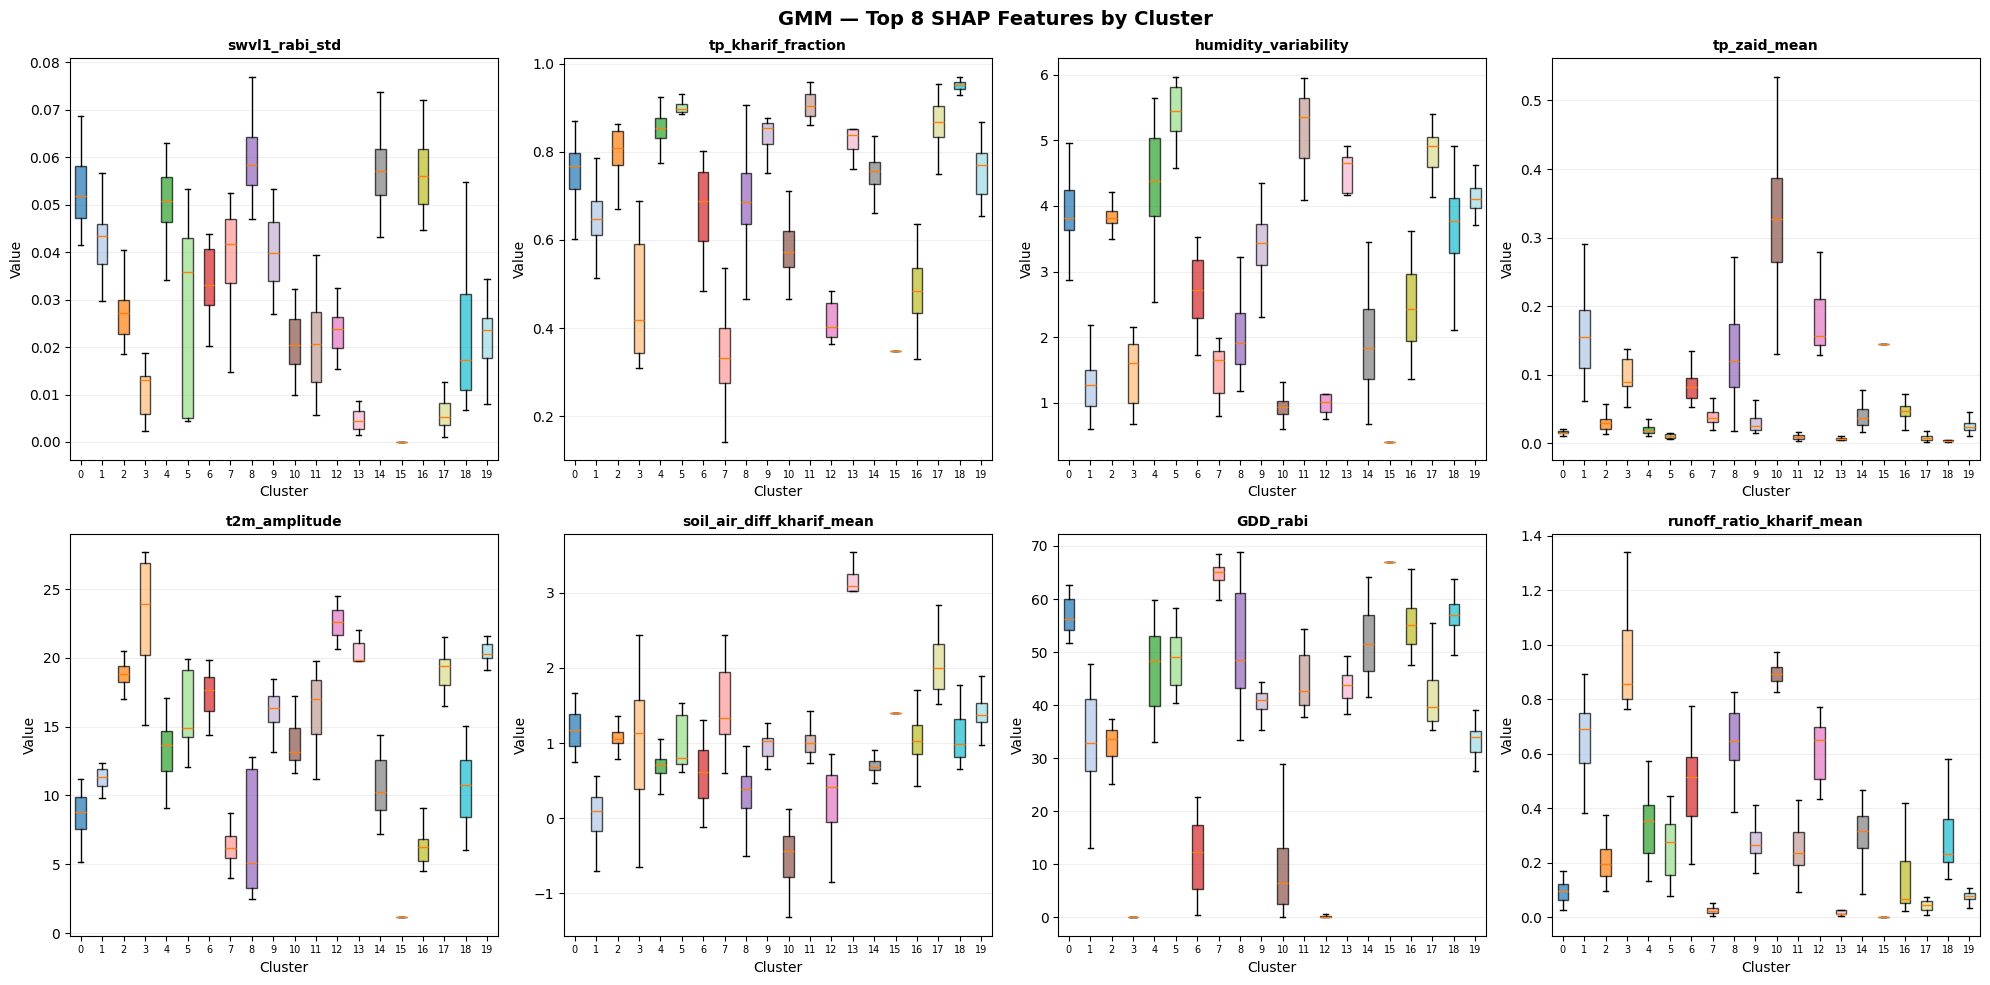

C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab20', n_clusters)
C:\Users\Atharva Jagtap\AppData\Local\Temp\ipykernel_416\3204835162.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_ = plt.cm.get_cmap('tab

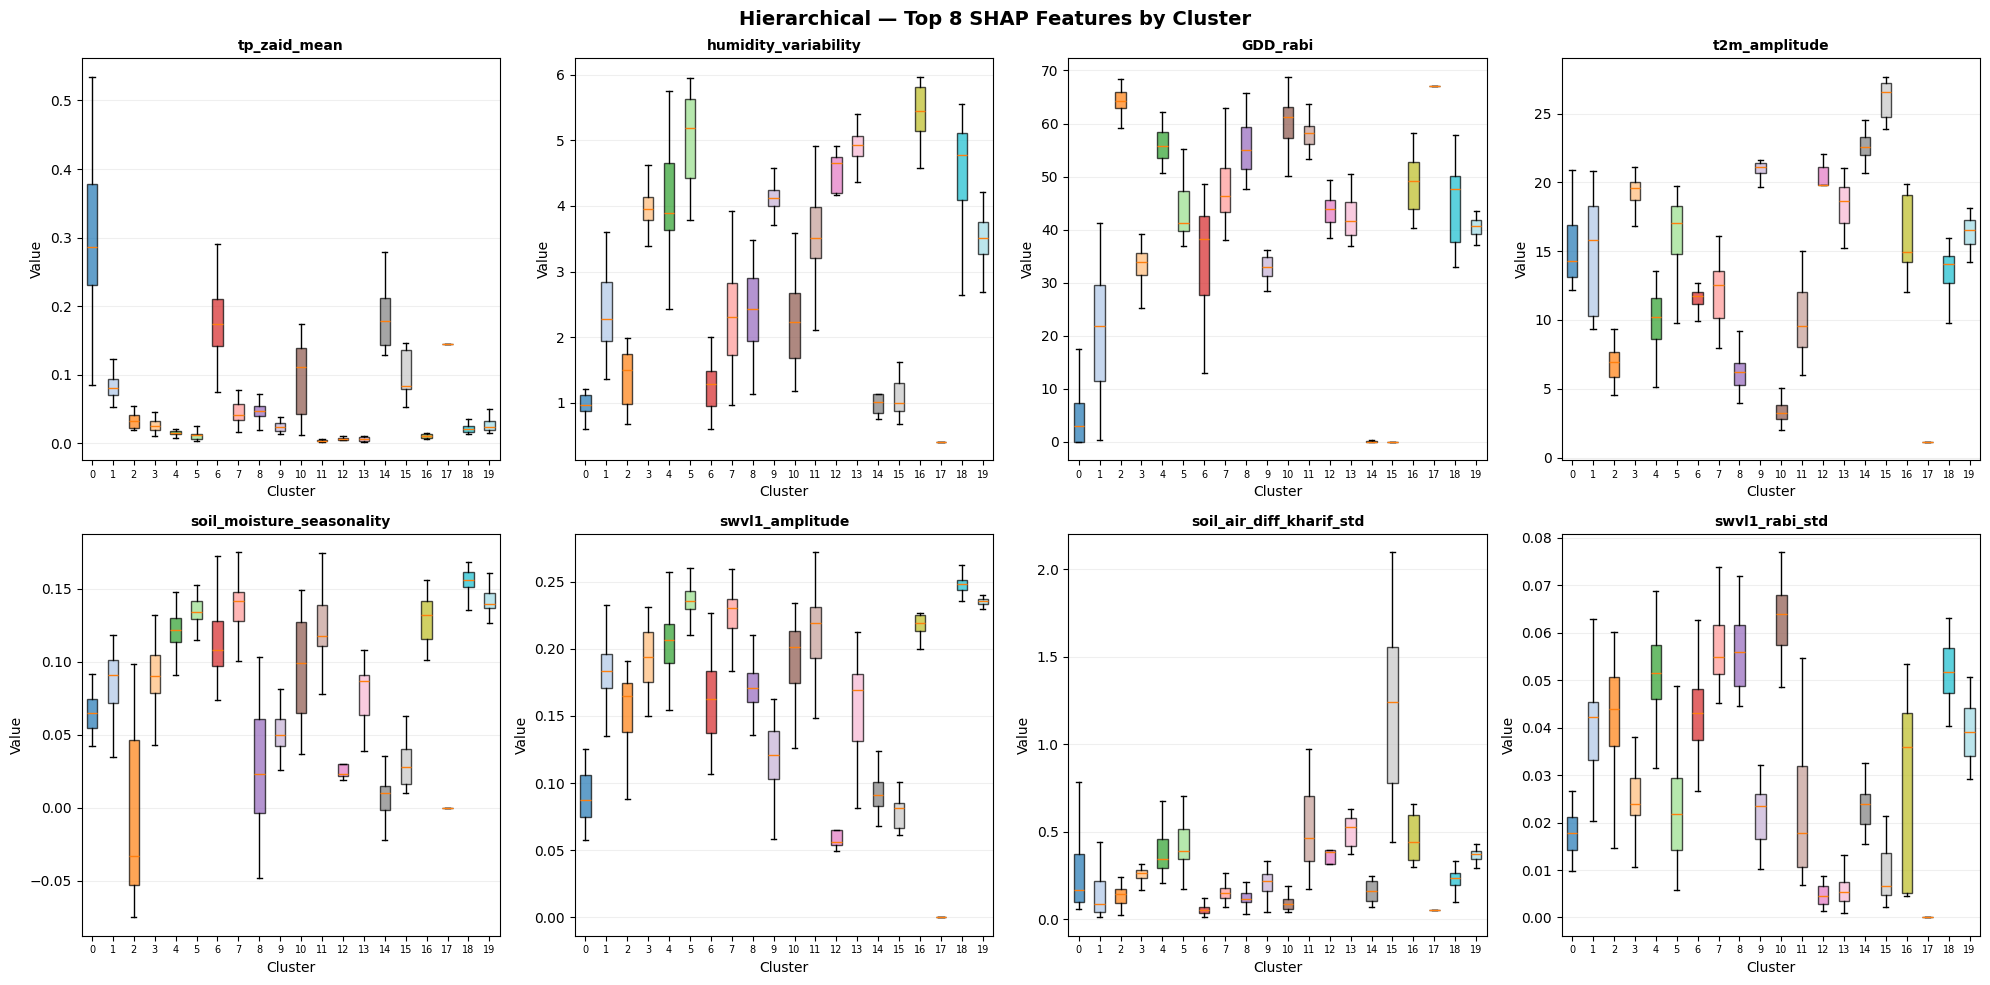

In [128]:
# ── Step 1: Cluster mean heatmap ──────────────────────────────────────────
for algo_name, df in [
    ("KMeans",       kmeans_df),
    ("GMM",          gmm_df),
    ("Hierarchical", hier_df),
]:
    cluster_means = (
        df[feature_cols + ['cluster']]
        .groupby('cluster')
        .mean()
    )
    # Z-score across clusters so all features are on same scale
    cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

    fig, ax = plt.subplots(figsize=(22, 7))
    sns.heatmap(
        cluster_means_z.T,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        linewidths=0.3,
        annot=False,
        xticklabels=[f'C{i}' for i in cluster_means_z.index],
        yticklabels=feature_cols
    )
    ax.set_title(f"{algo_name} — Cluster Mean Profile (Z-scored)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f"cluster_heatmap_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

# ── Step 2: Boxplots for top SHAP features only ───────────────────────────
top_n = 8

for algo_name, df, imp in [
    ("KMeans",       kmeans_df, imp_kmeans),
    ("GMM",          gmm_df,    imp_gmm),
    ("Hierarchical", hier_df,   imp_hier),
]:
    top_features = imp.head(top_n)['feature'].tolist()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    fig.suptitle(f"{algo_name} — Top {top_n} SHAP Features by Cluster", 
                 fontsize=14, fontweight='bold')

    for i, feat in enumerate(top_features):
        ax = axes[i]
        data_per_cluster = [
            df[df['cluster'] == c][feat].values
            for c in sorted(df['cluster'].unique())
        ]
        bp = ax.boxplot(data_per_cluster, patch_artist=True, showfliers=False)

        # Color each box by cluster
        cmap_ = plt.cm.get_cmap('tab20', n_clusters)
        for j, patch in enumerate(bp['boxes']):
            patch.set_facecolor(cmap_(j))
            patch.set_alpha(0.7)

        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Value')
        ax.set_xticks(range(1, n_clusters + 1))
        ax.set_xticklabels([str(c) for c in sorted(df['cluster'].unique())], fontsize=7)
        ax.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig(f"cluster_boxplots_{algo_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()